In [1]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd
from sympy import *
from sympy import Symbol, solveset, S, erf, log, sqrt
init_printing(use_unicode=True)

import scipy.optimize as optimize

In [57]:
def U_D(gamma_1,gamma_0,C_1,r,delta):
    return (1-delta)*np.dot(r,gamma_1) - np.dot(np.dot(np.subtract(gamma_1,gamma_0),C_1),np.subtract(gamma_1,gamma_0))

#U_D = term0 * alpha_0 + termA*beta_0^2 + termB&beta_0 + termC
def get_UD_zero_levelset_terms(C_1,r,delta,theta):
    term0 = (1-delta)*r[0]
    termC = ((1-delta)**2/(4*C_1[0,0]) 
             + (1-delta)*r[1]*theta 
             - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0]) 
             + C_1[0,1]**2 * theta**2 / C_1[0,0]
             - C_1[1,1]*theta**2
            )
    termB = (C_1[0,1]*(1-delta)*r[0] / C_1[0,0]
             - 2*C_1[0,1]**2 * theta / C_1[0,0]
             + 2*C_1[1,1]*theta
            )
    termA = (C_1[0,1]**2 / C_1[0,0]
             - C_1[1,1]
            )
    return term0,termA,termB,termC

def D_strategy(gamma_0,C_1,r,delta,theta):
    if sum(np.equal(gamma_0,[-.1,-.1]))==2:
        return np.array([-.1,-.1]),-.1,"abstain"
    #Abstain condition
    alpha_0 = gamma_0[0]
    beta_0 = gamma_0[1]
    #This is the version without cross-terms
    #abstain_quadratic_A = -C_1[1,1]
    #abstain_quadratic_B = (C_1[0,1]*(1-delta)*r[0]/C_1[0,0]) + 2*theta*C_1[1,1]
    #abstain_quadratic_C = ((1-delta)**2 * r[0]**2 / (4*C_1[0,0])) + (1-delta)*r[1]*theta - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0])-C_1[1,1]*theta**2
    #if 0 > ((1-delta)*r[0])*alpha_0 + abstain_quadratic_A*beta_0**2 + abstain_quadratic_B*beta_0 + abstain_quadratic_C:
    #    return [-.1,-.1],"abstain",-0.1
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    #print(term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC)
    if 0 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC:
        return [-.1,-.1],-0.1,"abstain"
    
    #Closed-form solution
    gamma_candidate_1 = gamma_0 + 0.5 * (1-delta) * np.dot(np.linalg.inv(C_1),r)
    gamma_candidate_2 = np.array([alpha_0,np.max([beta_0+(1-delta)*r[1]/(2*C_1[1,1]),theta])]) #can likely remove the np.max() and theta option from this
    #Making a slight change here to account for cross-terms:
    gamma_candidate_3 = np.array([np.max([alpha_0,
                                          alpha_0+(1-delta)*r[0]/(2*C_1[0,0]) - (C_1[0,1]/C_1[0,0])*(theta-beta_0)]),
                                  np.max([beta_0,theta])
                                 ])
    
    #Omit unconstrained candidate if it is infeasible
    if gamma_candidate_1[0]<alpha_0 or gamma_candidate_1[1]<np.max([beta_0,theta]):
        candidates = [gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
    else:
        candidates = [gamma_candidate_1,gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['unconstrained', 'constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
        
    #print(candidates)
    #Strategy list for explaining remaining candidates
    strategies = [strategy_list[i] for i in range(len(candidates))]
    
    #Evaluate utilities for remaining candidates
    utilities = [U_D(candidates[i],gamma_0,C_1,r,delta) for i in range(len(candidates))]
    index_choice = np.argmax(utilities)
    
    return candidates[index_choice], utilities[index_choice], strategies[index_choice]
    
def U_G(gamma_0,C_0,C_1,r,delta,theta):
    return delta*np.dot(r,D_strategy(gamma_0,C_1,r,delta,theta)[0]) - np.dot(np.dot(gamma_0,C_0),gamma_0)

def get_candidates(C_0,C_1,delta,r,theta,thetaG,epsilon=0.000001):
    a, b, l = symbols('a b l',real=True)
    C_0_rat = np.array([[Rational(C_0[0,0]),Rational(C_0[0,1])],[Rational(C_0[1,0]),Rational(C_0[1,1])]])
    C_1_rat = np.array([[Rational(C_1[0,0]),Rational(C_1[0,1])],[Rational(C_1[1,0]),Rational(C_1[1,1])]])
    delta_rat = Rational(delta)#0.5
    theta_rat = Rational(theta)
    thetaG_rat = Rational(thetaG)
    r_rat = np.array([Rational(r[0]),Rational(r[1])])
    equation_1 = delta_rat*r_rat[0] - 2*C_0_rat[0,0]*a - 2*C_0_rat[0,1]*b - l*(1-delta_rat)*r_rat[0]
    equation_2 = (delta_rat*C_1_rat[0,1]*r_rat[0]/C_1_rat[0,0]) - 2*C_0_rat[1,1]*b - 2*C_0_rat[0,1]*a - l*(C_1_rat[0,1]*(1-delta_rat)*r_rat[0]/C_1_rat[0,0] - 2*C_1_rat[0,1]**2 * theta_rat/C_1_rat[0,0] + 2*C_1_rat[1,1]*theta_rat + 2*(C_1_rat[0,1]/C_1_rat[0,0]-C_1_rat[1,1])*b)
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1_rat,r_rat,delta_rat,theta_rat)
    equation_3 = term0*a + termA*b**2 + termB*b + termC
    raw_results = solve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)#nonlinsolve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)
    raw_results = list(raw_results)
    #print(Float(raw_results,10))
    #print(np.array(raw_results).shape)
    #print(raw_results[0][0])
    results = []
    for i in range(len(raw_results)):
        if isinstance(raw_results[i][0], complex) or isinstance(raw_results[i][1], complex):
            continue
        if ("I" in str(raw_results[i][0]))or("I" in str(raw_results[i][1])):
            continue
        #if N(raw_results[i][0])>1000 or N(raw_results[i][1])>1000:
        #    print("Very large number.")
        #    continue
        results = results + [np.array([N(raw_results[i][j])+epsilon for j in range(2)])]#[np.add(raw_results[i][:2],epsilon)]#[np.array([N(raw_results[i][j])+epsilon for j in range(2)])]
    #results = [np.add(raw_results[i][:2],epsilon) for i in range(len(raw_results))]
    return results

def G_strategy(C_0,C_1,r,delta,theta,thetaG,epsilon=0.000001):
    candidate_1 = 0.5*delta*np.dot(np.linalg.inv(C_0),r)
    candidate_2 = np.array([0,np.max([delta*r[1]/(2*C_0[1,1]),thetaG])])
    candidate_3 = np.array([np.max([0,delta*r[0]/(2*C_0[0,0]) - (C_0[0,1]/C_0[0,0])*thetaG]),thetaG])
    
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    candidate_5 = [(-1/term0)*(termA*thetaG**2 + termB*thetaG + termC)+epsilon,thetaG+epsilon]
    candidate_6_beta_options = np.real(np.roots([termA,termB,termC]))
    candidate_6_1 = np.array([0+epsilon,candidate_6_beta_options[0]+epsilon])
    candidate_6_2 = np.array([0+epsilon,candidate_6_beta_options[1]+epsilon])
    candidate_7 = np.array([0,thetaG])

    candidate_4_candidates = get_candidates(C_0,C_1,delta,r,theta,thetaG)
    
    candidates_all = [candidate_1, candidate_2,candidate_3,candidate_5,candidate_6_1,candidate_6_2,candidate_7]+candidate_4_candidates
    strategies_all = ['unconstrained','$\\alpha_0=0$','$\\beta_0=\\theta_G$','$U_D=0, \\beta_0=\\theta_G$','$U_D=0, \\alpha_0=0$','$U_D=0, \\alpha_0=0$','$\\alpha_0=0,\\beta_0=\\theta_G$']+["$U_D=0$"]*len(candidate_4_candidates)
    utilities_all = [U_G(g0,C_0,C_1,r,delta,theta) for g0 in candidates_all]

    #Filter infeasible options going back to front
    i = len(candidates_all)-1
    while i>=0:
        #print(strategies_all)
        #for index in np.linspace(len(candidates_all),0):
        #i = int(index)
        #print(i)
        #-0.0001 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC: 
        if U_D(D_strategy(candidates_all[i],C_1,r,delta,theta)[0],candidates_all[i],C_1,r,delta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif U_G(candidates_all[i],C_0,C_1,r,delta,theta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif (candidates_all[i][0]<0)|(candidates_all[i][1]<thetaG):
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        i = i-1
    
    if len(candidates_all)<=0:
        return np.array([-.1,-.1]),-.1,"abstain"
    
    choice = np.argmax(utilities_all)
    
    if candidates_all[choice][0]<=0:
        print("Strange case: ")
        print(C_0,C_1,r,delta,theta,thetaG)
        print("Choice: ",candidates_all[choice], utilities_all[choice], strategies_all[choice])
        print("All candidates: ",candidates_all)
        print("All utilities: ",utilities_all)
        print("All strategies: ",strategies_all)
        print("D response and utility: ",D_strategy(candidates_all[i],C_1,r,delta,theta))
    
    return candidates_all[choice], utilities_all[choice], strategies_all[choice]
    

In [58]:
C_0 = np.array([[1,0],[0,1]])
C_1 = np.array([[1,0],[0,1]])
delta = 0.5
theta = .01#1.5
thetaG = .4
r = np.array([1,1])

gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,theta,thetaG)
print(gamma_0, u_g0, stratGex )
print()
print(D_strategy(gamma_0,C_1,r,delta,theta))

[0.25 0.4 ] 0.3524999999999999 $\beta_0=\theta_G$

(array([0.5 , 0.65]), np.float64(0.44999999999999996), 'unconstrained')


In [59]:
D_strategy(gamma_0,C_1,r,delta,theta)


(array([0.5 , 0.65]), np.float64(0.44999999999999996), 'unconstrained')

In [ ]:
thetaGs = np.linspace(0,1.5,151)
thetaDs = np.linspace(0,2.5,251)

G_strategy_results = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy','backfiring_flag'])
G_strategy_results['C0']=[None]*10000

index = 0
for gt in thetaGs:
    print(gt)
    # Iterate from gt to 2.5 in steps of 0.025
    for t in thetaDs:
        if t<gt:
            continue
        #for t in np.linspace(gt,2.5,int(np.round((2.5-gt)*30))+1):
        gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,delta,t,gt)
        gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,delta,t)
        alpha_0 = gamma_0[0]
        beta_0 = gamma_0[1]
        alpha_1 = gamma_1[0]
        beta_1 = gamma_1[1]
        G_strategy_results.at[index,'C0']=str(C_0)
        G_strategy_results.at[index,'C1']=str(C_1)
        G_strategy_results.at[index,'r']=str(r)
        G_strategy_results.at[index,'delta']=delta
        G_strategy_results.at[index,'theta']=t
        G_strategy_results.at[index,'thetaG']=gt
        G_strategy_results.at[index,'alpha_0']=float(alpha_0)
        G_strategy_results.at[index,'beta_0']=float(beta_0)
        G_strategy_results.at[index,'alpha_1']=float(alpha_1)
        G_strategy_results.at[index,'beta_1']=float(beta_1)
        G_strategy_results.at[index,'U_G']=float(UG)
        G_strategy_results.at[index,'U_D']=float(UD)
        G_strategy_results.at[index,'Gstrategy']=strategyG
        G_strategy_results.at[index,'Dstrategy']=strategyD
        if t==gt:
            beta_1_anarchy=beta_1
        if beta_1 < beta_1_anarchy:
            G_strategy_results.at[index,'backfiring_flag']=1
        else:
            G_strategy_results.at[index,'backfiring_flag']=0
        index = index + 1


0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36
0.37
0.38
0.39
0.4
0.41000000000000003
0.42
0.43
0.44
0.45
0.46
0.47000000000000003
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001


In [78]:
G_strategy_results

,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,backfiring_flag,beta_0
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.0,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0,0.25
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.025,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0,0.25
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.05,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0,0.25
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.075,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0,0.25
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0.1,0.0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
G_strategy_results_save = G_strategy_results
G_strategy_results = G_strategy_results.dropna()

In [80]:
G_strategy_results['U_pareto']=0
G_strategy_results['U_pareto_dominates_anarchy']=0
G_strategy_results['U_dominates_anarchy']=0

anarchy_UG = np.max(G_strategy_results[(G_strategy_results['theta']<0.05)&(G_strategy_results['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(G_strategy_results[(G_strategy_results['theta']<0.05)&(G_strategy_results['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*G_strategy_results['U_G'],(1-weight)*G_strategy_results['U_D']))
    G_strategy_results.loc[idx,'U_pareto']=1
    if G_strategy_results.loc[idx,'U_G']>anarchy_UG and G_strategy_results.loc[idx,'U_D']>anarchy_UD:
        G_strategy_results.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(G_strategy_results)):
    if G_strategy_results.loc[i,'U_G']>anarchy_UG and G_strategy_results.loc[i,'U_D']>anarchy_UD:
        G_strategy_results.loc[i,'U_dominates_anarchy']=1
        

/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/135035055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_strategy_results['U_pareto']=0
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/135035055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_strategy_results['U_pareto_dominates_anarchy']=0
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/135035055.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

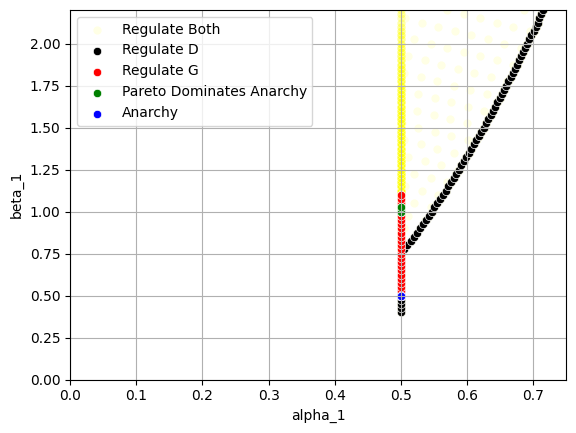

In [81]:
#sns.scatterplot(data=G_strategy_results,x='alpha_0',y='beta_0',hue='thetaG',alpha=.5)
sns.scatterplot(data=G_strategy_results,x='alpha_1',y='beta_1',color='yellow',alpha=.1,label='Regulate Both')
sns.scatterplot(data=G_strategy_results[G_strategy_results['thetaG']==0],x='alpha_1',y='beta_1',color='black',alpha=1,label='Regulate D')
sns.scatterplot(data=G_strategy_results[G_strategy_results['theta']<=G_strategy_results['thetaG']],x='alpha_1',y='beta_1',color='red',alpha=1,label='Regulate G')
sns.scatterplot(data=G_strategy_results[G_strategy_results['U_pareto_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto Dominates Anarchy')
#sns.scatterplot(data=G_strategy_results[G_strategy_results['U_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto Dominates Anarchy')
sns.scatterplot(data=G_strategy_results[(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='alpha_1',y='beta_1',color='blue',alpha=1,label='Anarchy')
plt.grid()
plt.legend()

plt.xlim([0,.75])
plt.ylim([0,2.2])

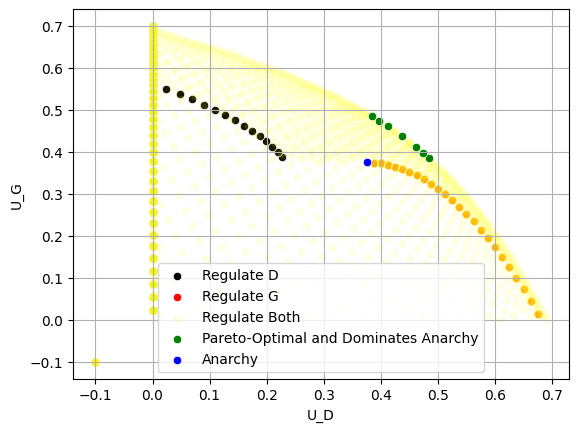

In [82]:
#sns.scatterplot(data=G_strategy_results,x='alpha_0',y='beta_0',hue='thetaG',alpha=.5)
sns.scatterplot(data=G_strategy_results[G_strategy_results['thetaG']==0],x='U_D',y='U_G',color='black',alpha=1,label='Regulate D')
sns.scatterplot(data=G_strategy_results[G_strategy_results['theta']<=G_strategy_results['thetaG']],x='U_D',y='U_G',color='red',alpha=1,label='Regulate G')
sns.scatterplot(data=G_strategy_results,x='U_D',y='U_G',color='yellow',alpha=.1,label='Regulate Both')
#sns.scatterplot(data=G_strategy_results[G_strategy_results['U_pareto']==1],x='U_D',y='U_G',color='green',alpha=1,label='Pareto-Optimal')
sns.scatterplot(data=G_strategy_results[G_strategy_results['U_pareto_dominates_anarchy']==1],x='U_D',y='U_G',color='green',alpha=1,label='Pareto-Optimal and Dominates Anarchy')
#sns.scatterplot(data=G_strategy_results[G_strategy_results['U_dominates_anarchy']==1],x='U_D',y='U_G',color='green',alpha=1,label='Dominates Anarchy')

sns.scatterplot(data=G_strategy_results[(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='U_D',y='U_G',color='blue',alpha=1,label='Anarchy')
plt.grid()

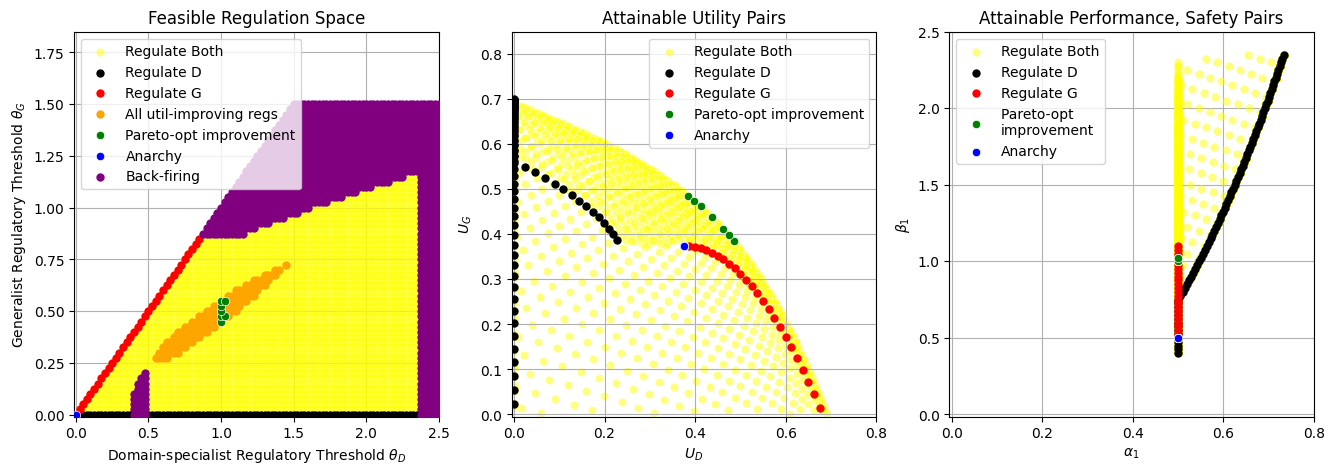

In [83]:
fix,ax = plt.subplots(1,3,figsize=[16,5])

sns.scatterplot(data=G_strategy_results[G_strategy_results['U_D']>=0],x='theta',y='thetaG',alpha=.5,color='yellow',label='Regulate Both',linewidth=0,ax=ax[0],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='theta',y='thetaG',color='black',alpha=1,linewidth=0,label='Regulate D',ax=ax[0],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='theta',y='thetaG',color='red',linewidth=0,alpha=1,label='Regulate G',ax=ax[0],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_dominates_anarchy']==1)],x='theta',y='thetaG',color='orange',linewidth=0,alpha=1,label='All util-improving regs',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='theta',y='thetaG',color='green',alpha=1,label='Pareto-opt improvement',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.01)&(G_strategy_results['thetaG']<0.01)],x='theta',y='thetaG',color='blue',alpha=1,label='Anarchy',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['beta_1']<0.5)],x='theta',y='thetaG',color='purple',alpha=1,linewidth=0,label='Back-firing',ax=ax[0],zorder=5)
ax[0].set_xlabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_ylabel("Generalist Regulatory Threshold $\\theta_G$")
ax[0].grid(zorder=-10)
ax[0].set_title("Feasible Regulation Space")
ax[0].legend()
ax[0].set_ylim([-0.01,1.85])
ax[0].set_xlim([-0.013,2.5])


ax[1].grid(zorder=-10)
sns.scatterplot(data=G_strategy_results,x='U_D',y='U_G',color='yellow',alpha=.5,label='Regulate Both',ax=ax[1])
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='U_D',y='U_G',color='black',linewidth=0,alpha=1,label='Regulate D',ax=ax[1],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='U_D',y='U_G',color='red',linewidth=0,alpha=1,label='Regulate G',ax=ax[1],zorder=6)
#sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_dominates_anarchy']==1)],x='U_D',y='U_G',color='orange',linewidth=0,alpha=1,label='All util-improving regs',ax=ax[1],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='U_D',y='U_G',color='green',alpha=1,label='Pareto-opt improvement',ax=ax[1],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='U_D',y='U_G',color='blue',alpha=1,label='Anarchy',ax=ax[1],zorder=6)
ax[1].set_xlim([-0.005,.8])
ax[1].set_ylim([-0.005,.85])
ax[1].set_title("Attainable Utility Pairs")
ax[1].set_xlabel('$U_D$')
ax[1].set_ylabel('$U_G$')

sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)],x='alpha_1',y='beta_1',color='yellow',alpha=.5,label='Regulate Both',linewidth=0,ax=ax[2],zorder=6)
#sns.scatterplot(data=G_strategy_results[G_strategy_results['U_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='orange',alpha=1,ax=ax[2],linewidth=0,label='Improvement region',zorder=7)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='alpha_1',y='beta_1',color='black',alpha=1,label='Regulate D',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='alpha_1',y='beta_1',color='red',alpha=1,label='Regulate G',linewidth=0,ax=ax[2],zorder=8)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto-opt \nimprovement',ax=ax[2],zorder=8)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='alpha_1',y='beta_1',color='blue',alpha=1,label='Anarchy',ax=ax[2],zorder=8)
ax[2].grid()
ax[2].set_xlim([-0.005,.8])
ax[2].set_ylim([-0.015,2.5])
ax[2].set_title("Attainable Performance, Safety Pairs")
ax[2].set_xlabel('$\\alpha_1$')
ax[2].set_ylabel('$\\beta_1$')

plt.savefig('multivariate_analysis_pareto_regulation_jun3.png',bbox_inches='tight',dpi=200)


In [109]:
G_strategy_results.loc[61,'beta_1']

/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/2214455004.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  beta_1_values[j,i] = G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])]['beta_1']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/2214455004.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_G_values[j,i] = G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])]['U_G']
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/2214455004.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  U_D_values[j,i] = G_strategy_results[(G_strategy_r

AttributeError: 'Axes' object has no attribute 'colorbar'

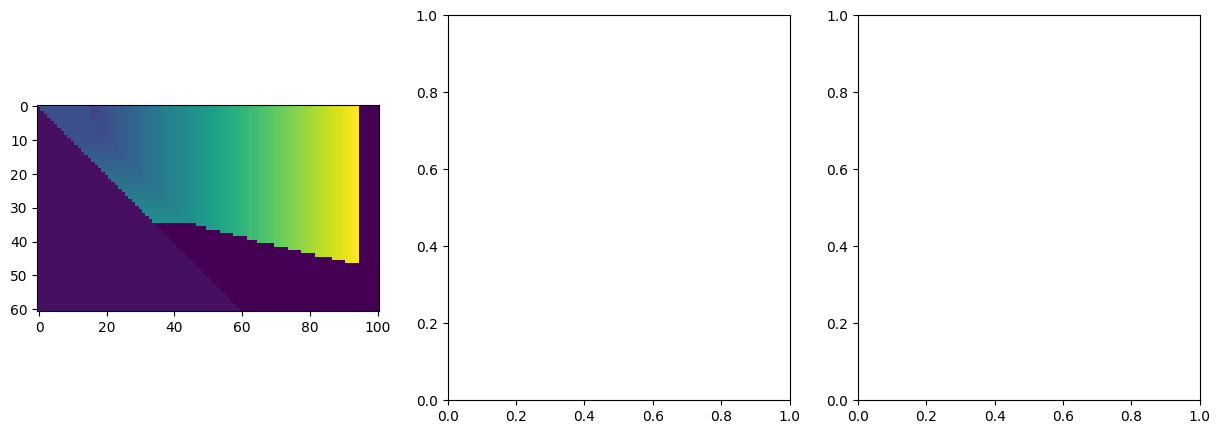

In [ ]:
# Create a heatmap of the combinations of thetaDs and thetaGs that are feasible.

# grid
ThetaDs, ThetaGs = np.meshgrid(thetaDs, thetaGs)
beta_1_values = np.zeros(ThetaDs.shape)
U_G_values = np.zeros(ThetaDs.shape)
U_D_values = np.zeros(ThetaDs.shape)


# Create a heatmap of the combinations of thetaDs and thetaGs that are appear in the G_strategy_results dataframe
#index = 0
for i in range(len(thetaDs)):
    for j in range(len(thetaGs)):
        if len(G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])])>0:
            beta_1_values[j,i] = G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])]['beta_1']
            U_G_values[j,i] = G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])]['U_G']
            U_D_values[j,i] = G_strategy_results[(G_strategy_results['theta']==thetaDs[i])&(G_strategy_results['thetaG']==thetaGs[j])]['U_D']
        #index = index + 1

# Now visualize the feasible_regulations matrix
fig, ax = plt.subplots(1,3,figsize=[15,5])
ax[0].imshow(beta_1_values, cmap='viridis')
ax[0].set_title('$\\beta_1$')
ax[1].imshow(U_G_values, cmap='viridis')
ax[1].set_title('$U_G$')
ax[2].imshow(U_D_values, cmap='viridis')
ax[2].set_title('$U_D$')
plt.show()



/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/4104839052.py:36: UserWarning: The following kwargs were not used by contour: 'label'
  ax[0].contour(backfiring_data, colors='red', levels=[0], linewidths=1, label='Back-firing region')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/4104839052.py:58: UserWarning: The following kwargs were not used by contour: 'label'
  ax[1].contour(improvement_data, colors='green', levels=[0.0], linewidths=1, label='Improvement region')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/4104839052.py:79: UserWarning: The following kwargs were not used by contour: 'label'
  ax[2].contour(improvement_data, colors='green', levels=[0.0], linewidths=1, label='Improvement region')
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/4104839052.py:113: UserWarning: The following kwargs were not used by contour: 'label'
  ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Pareto 

thetaGs  0.000  0.025  0.050  0.075  0.100  0.125  0.150  0.175  0.200  0.225  \
thetaDs                                                                         
0.000    False  False  False  False  False  False  False  False  False  False   
0.025    False  False  False  False  False  False  False  False  False  False   
0.050    False  False  False  False  False  False  False  False  False  False   
0.075    False  False  False  False  False  False  False  False  False  False   
0.100    False  False  False  False  False  False  False  False  False  False   

thetaGs  ...  1.275  1.300  1.325  1.350  1.375  1.400  1.425  1.450  1.475  \
thetaDs  ...                                                                  
0.000    ...  False  False  False  False  False  False  False  False  False   
0.025    ...  False  False  False  False  False  False  False  False  False   
0.050    ...  False  False  False  False  False  False  False  False  False   
0.075    ...  False  False  False  Fa

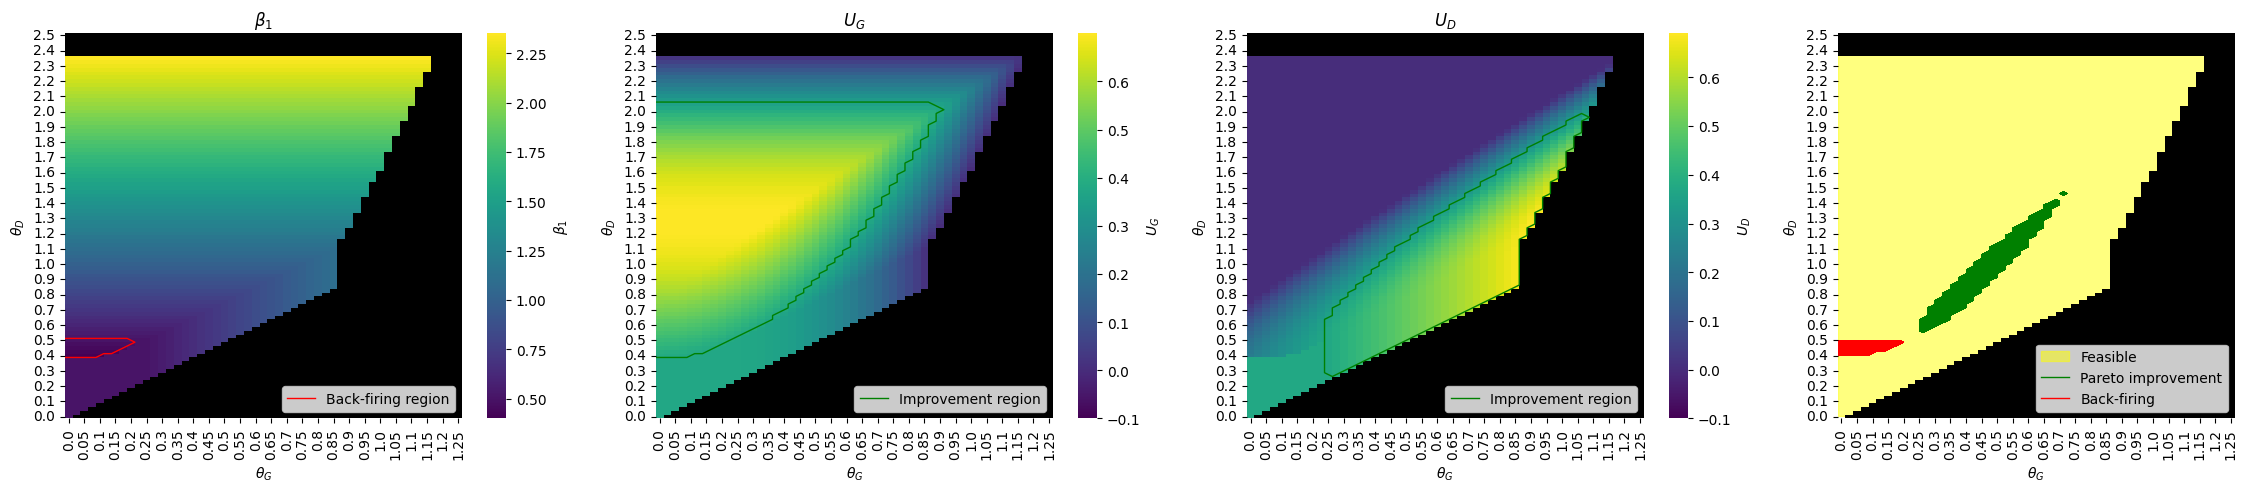

In [265]:
# On the x axis is thetaGs, on the y axis is thetaDs, the color is the give by feasible_regulations 
fig, ax = plt.subplots(1,4,figsize=[28,5], width_ratios=[1,1,1,.8])

data_for_heatmap = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'beta_1': beta_1_values.flatten()})

# Round thetaDs and thetaGs to 3 decimal places
data_for_heatmap['thetaDs'] = data_for_heatmap['thetaDs'].round(3)
data_for_heatmap['thetaGs'] = data_for_heatmap['thetaGs'].round(3)

# Filter out thetaG values above 1.25
data_for_heatmap = data_for_heatmap[data_for_heatmap['thetaGs'] <= 1.25]

# Create pivot table for heatmap
pivot_data = data_for_heatmap.pivot(index='thetaDs', columns='thetaGs', values='beta_1')

# Plot in BLACK anywwhere that beta_1 is <=0
pivot_data[pivot_data <= 0] = np.nan
infeasible_data = pivot_data.copy().fillna(0)
infeasible_data[infeasible_data > 0] = np.nan

# Invert the y axis
pivot_data = pivot_data.iloc[::-1]
infeasible_data = infeasible_data.iloc[::-1]

# Create heatmap
sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': '$\\beta_1$'}, ax=ax[0])
sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[0])

# Outline in red anywhere that beta_1 is <0.5
backfiring_data = pivot_data.copy()
backfiring_data[backfiring_data >= 0.5] = np.nan
backfiring_data[backfiring_data <= 0] = np.nan
backfiring_data = backfiring_data.fillna(0)

# Instead of a heatmap, plot as a contour plot the outline of the backfiring_data. There should be a corresponding entry in the legend for the backfiring region. Make sure the legend populates.
ax[0].contour(backfiring_data, colors='red', levels=[0], linewidths=1, label='Back-firing region')
ax[0].set_xlabel('$\\theta_G$')
ax[0].set_ylabel('$\\theta_D$')
ax[0].plot([], [], color='red', linewidth=1, label='Back-firing region')
ax[0].legend(loc='lower right')
# On the second plot, plot the U_G values as a the heatmap data

data_for_heatmap_2 = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'U_G': U_G_values.flatten()})
data_for_heatmap_2['thetaDs'] = data_for_heatmap_2['thetaDs'].round(3)
data_for_heatmap_2['thetaGs'] = data_for_heatmap_2['thetaGs'].round(3)
pivot_data = data_for_heatmap_2.pivot(index='thetaDs', columns='thetaGs', values='U_G')

pivot_data = pivot_data.iloc[::-1]
sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': '$U_G$'}, ax=ax[1])
sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[1])

# What is the value of the utility at theta_G = 0 and theta_D = 0?
basline_ug = pivot_data.loc[0,0]
# Create a contour plot to outline the improvement region
improvement_data = pivot_data.copy()
improvement_data[improvement_data <= basline_ug] = 0

ax[1].contour(improvement_data, colors='green', levels=[0.0], linewidths=1, label='Improvement region')
# Set the colorbar with limits 0, 1.
ax[1].set_xlabel('$\\theta_G$')
ax[1].set_ylabel('$\\theta_D$')
ax[1].plot([], [], color='green', linewidth=1, label='Improvement region')
ax[1].legend(loc='lower right')


# On the third plot, plot the U_D values as a the heatmap data
data_for_heatmap_3 = pd.DataFrame({'thetaGs': ThetaGs.flatten(), 'thetaDs': ThetaDs.flatten(), 'U_D': U_D_values.flatten()})
data_for_heatmap_3['thetaDs'] = data_for_heatmap_3['thetaDs'].round(3)
data_for_heatmap_3['thetaGs'] = data_for_heatmap_3['thetaGs'].round(3)
pivot_data = data_for_heatmap_3.pivot(index='thetaDs', columns='thetaGs', values='U_D')
pivot_data = pivot_data.iloc[::-1]
sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': '$U_D$'}, ax=ax[2])
sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[2])

# What is the value of the utility at theta_G = 0 and theta_D = 0?
basline_ud = pivot_data.loc[0,0]
improvement_data = pivot_data.copy()
improvement_data[improvement_data <= basline_ud] = 0
ax[2].contour(improvement_data, colors='green', levels=[0.0], linewidths=1, label='Improvement region')
ax[2].set_xlabel('$\\theta_G$')
ax[2].set_ylabel('$\\theta_D$')
ax[2].plot([], [], color='green', linewidth=1, label='Improvement region')
ax[2].legend(loc='lower right')

ax[0].set_title('$\\beta_1$')
ax[1].set_title('$U_G$')
ax[2].set_title('$U_D$')

# Plot a constant color for all the values in infeasible_data
feasible_data = pivot_data.copy()
feasible_data[feasible_data < 0] = np.nan
feasible_data[feasible_data >= 0] = 1

# Plot the entire x and y axis in yellow constant solid
# Use fill to fill a polygon
ax[3].fill([0,100.25,100.25,0],[0,0,100.25,100.25],color='yellow',alpha=0.5, label='Feasible')
ax[3].set_xlabel('$\\theta_G$')
ax[3].set_ylabel('$\\theta_D$')
ax[3].legend(loc='lower right')

# Plot a line representing the feasible regulations where theta_G = theta_D
data_for_finalplot = pd.DataFrame({'thetaGs': ThetaGs.flatten()
                                   , 'thetaDs': ThetaDs.flatten()
                                   , 'beta_1': beta_1_values.flatten()
                                   , 'U_G': U_G_values.flatten()
                                   , 'U_D': U_D_values.flatten()})
data_for_finalplot['backfiring'] = np.logical_and(np.less(data_for_finalplot['beta_1'], 0.5), np.greater(data_for_finalplot['beta_1'], 0))
data_for_finalplot['pareto_improvement'] = np.logical_and(np.greater(data_for_finalplot['U_G'], basline_ug), np.greater(data_for_finalplot['U_D'], basline_ud))

# Plot the pareto improvement region
pivot_data_pareto = data_for_finalplot.pivot(index='thetaDs', columns='thetaGs', values='pareto_improvement')
pivot_data_pareto = pivot_data_pareto.iloc[::-1]
ax[3].contourf(pivot_data_pareto, colors='green', levels=[0.5,1], label='Pareto improvement')
ax[3].plot([], [], color='green', linewidth=1, label='Pareto improvement')
#Plot the backfiring region
pivot_data_backfiring = data_for_finalplot.pivot(index='thetaDs', columns='thetaGs', values='backfiring')
print(pivot_data_backfiring.head())
pivot_data_backfiring = pivot_data_backfiring.iloc[::-1]
# Fill in the contour with a color
ax[3].contourf(pivot_data_backfiring, colors='red', levels=[0.5,1], label='Back-firing')
ax[3].plot([], [], color='red', linewidth=1, label='Back-firing')

ax[3].legend(loc='lower right')

# Plot black for all values in the infeasible set
sns.heatmap(infeasible_data, cmap='gray',cbar=False, ax=ax[3])
ax[3].set_xlabel('$\\theta_G$')
ax[3].set_ylabel('$\\theta_D$')
plt.show()
# #plt.colorbar()
#plt.show()

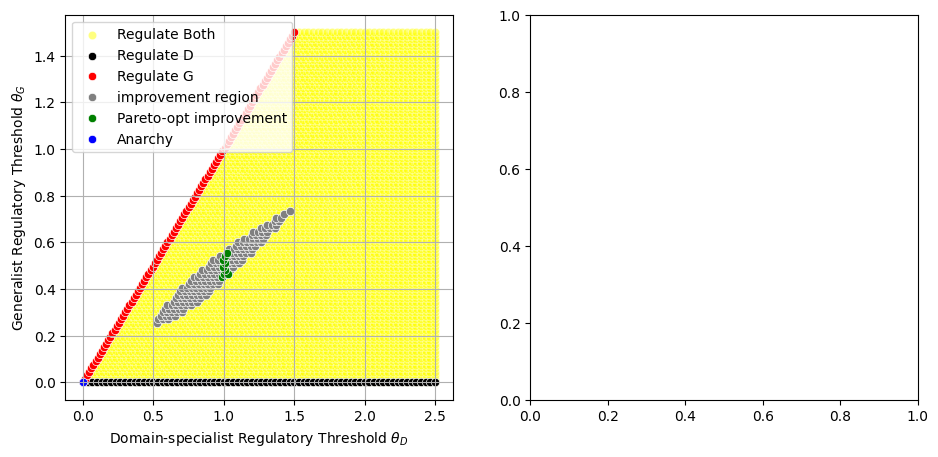

In [12]:
fix,ax = plt.subplots(1,2,figsize=[11,5])
sns.scatterplot(data=G_strategy_results,x='theta',y='thetaG',color='yellow',alpha=.5,label='Regulate Both',ax=ax[0])
sns.scatterplot(data=G_strategy_results[G_strategy_results['thetaG']==0],x='theta',y='thetaG',color='black',alpha=1,label='Regulate D',ax=ax[0])
sns.scatterplot(data=G_strategy_results[G_strategy_results['theta']<=G_strategy_results['thetaG']],x='theta',y='thetaG',color='red',alpha=1,label='Regulate G',ax=ax[0])
sns.scatterplot(data=G_strategy_results[G_strategy_results['U_dominates_anarchy']==1],x='theta',y='thetaG',color='gray',alpha=1,label='improvement region',ax=ax[0])
sns.scatterplot(data=G_strategy_results[G_strategy_results['U_pareto_dominates_anarchy']==1],x='theta',y='thetaG',color='green',alpha=1,label='Pareto-opt improvement',ax=ax[0])
sns.scatterplot(data=G_strategy_results[(G_strategy_results['theta']<0.01)&(G_strategy_results['thetaG']<0.01)],x='theta',y='thetaG',color='blue',alpha=1,label='Anarchy',ax=ax[0])
ax[0].set_xlabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_ylabel("Generalist Regulatory Threshold $\\theta_G$")
ax[0].grid()

In [13]:
G_strategy_results.to_csv("G_strategy_results_jun3.csv")

In [14]:
#Get Pareto-optimal classifiers
results_manip = G_strategy_results[G_strategy_results['theta']==G_strategy_results['theta']].copy()#.dropna()
results_manip = results_manip.sort_values(by=['U_G','U_D'],ascending=False).reset_index(drop=True)
results_manip['U_pareto']=0

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_manip['U_G'],(1-weight)*results_manip['U_D']))
    results_manip.loc[idx,'U_pareto']=1
    
    

In [15]:
#for weight in 

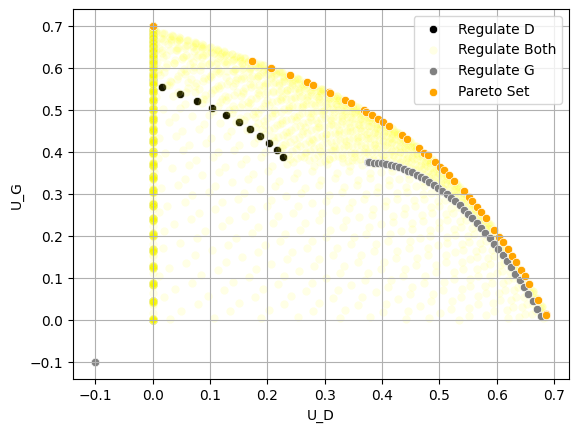

In [16]:
sns.scatterplot(data=G_strategy_results[G_strategy_results['thetaG']==0],x='U_D',y='U_G',color='black',alpha=1,label='Regulate D')
sns.scatterplot(data=G_strategy_results,x='U_D',y='U_G',color='yellow',alpha=.1,label='Regulate Both')
sns.scatterplot(data=G_strategy_results[G_strategy_results['theta']<=G_strategy_results['thetaG']],x='U_D',y='U_G',color='gray',alpha=1,label='Regulate G')
sns.scatterplot(data=results_manip[results_manip['U_pareto']==1],x='U_D',y='U_G',color='orange',alpha=1,label='Pareto Set')
plt.grid()


# Read in the pre-existing CSV

In [34]:
# Read in the preexisting csv
results_with_bargaining_old = pd.read_csv('multi_dimension_with_bargaining_data_duplicate_for_use.csv')
results_with_bargaining_old = pd.read_csv('multi_dimension_with_bargaining_data_foruse_two.csv')
print(f"Loaded {len(results_with_bargaining_old)} rows from existing data")
print(results_with_bargaining_old.head())


Loaded 49686 rows from existing data
   Unnamed: 0               C0               C1      r     delta  theta  \
0           0  [[1 0]\n [0 1]]  [[1 0]\n [0 1]]  [1 1]  0.010000    0.0   
1           1  [[1 0]\n [0 1]]  [[1 0]\n [0 1]]  [1 1]  0.020103    0.0   
2           2  [[1 0]\n [0 1]]  [[1 0]\n [0 1]]  [1 1]  0.030206    0.0   
3           3  [[1 0]\n [0 1]]  [[1 0]\n [0 1]]  [1 1]  0.040309    0.0   
4           4  [[1 0]\n [0 1]]  [[1 0]\n [0 1]]  [1 1]  0.050412    0.0   

   thetaG   alpha_0  alpha_1  beta_1       U_G       U_D      Gstrategy  \
0     0.0  0.005000      0.5     0.5  0.009950  0.499950  unconstrained   
1     0.0  0.010052      0.5     0.5  0.019901  0.499798  unconstrained   
2     0.0  0.015103      0.5     0.5  0.029750  0.499544  unconstrained   
3     0.0  0.020155      0.5     0.5  0.039497  0.499188  unconstrained   
4     0.0  0.025206      0.5     0.5  0.049142  0.498729  unconstrained   

       Dstrategy    beta_0  
0  unconstrained  0.005000  
1  

/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_42770/3255576808.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  optimal_deltas = results_with_bargaining_old.groupby(['theta', 'thetaG']).apply(


Found 507 optimal delta combinations
   theta  thetaG     delta    U_util
0   0.00     0.0  0.494948  0.749974
1   0.05     0.0  0.494948  0.749974
2   0.10     0.0  0.494948  0.749974
3   0.10     0.1  0.494948  0.749974
4   0.15     0.0  0.494948  0.749974


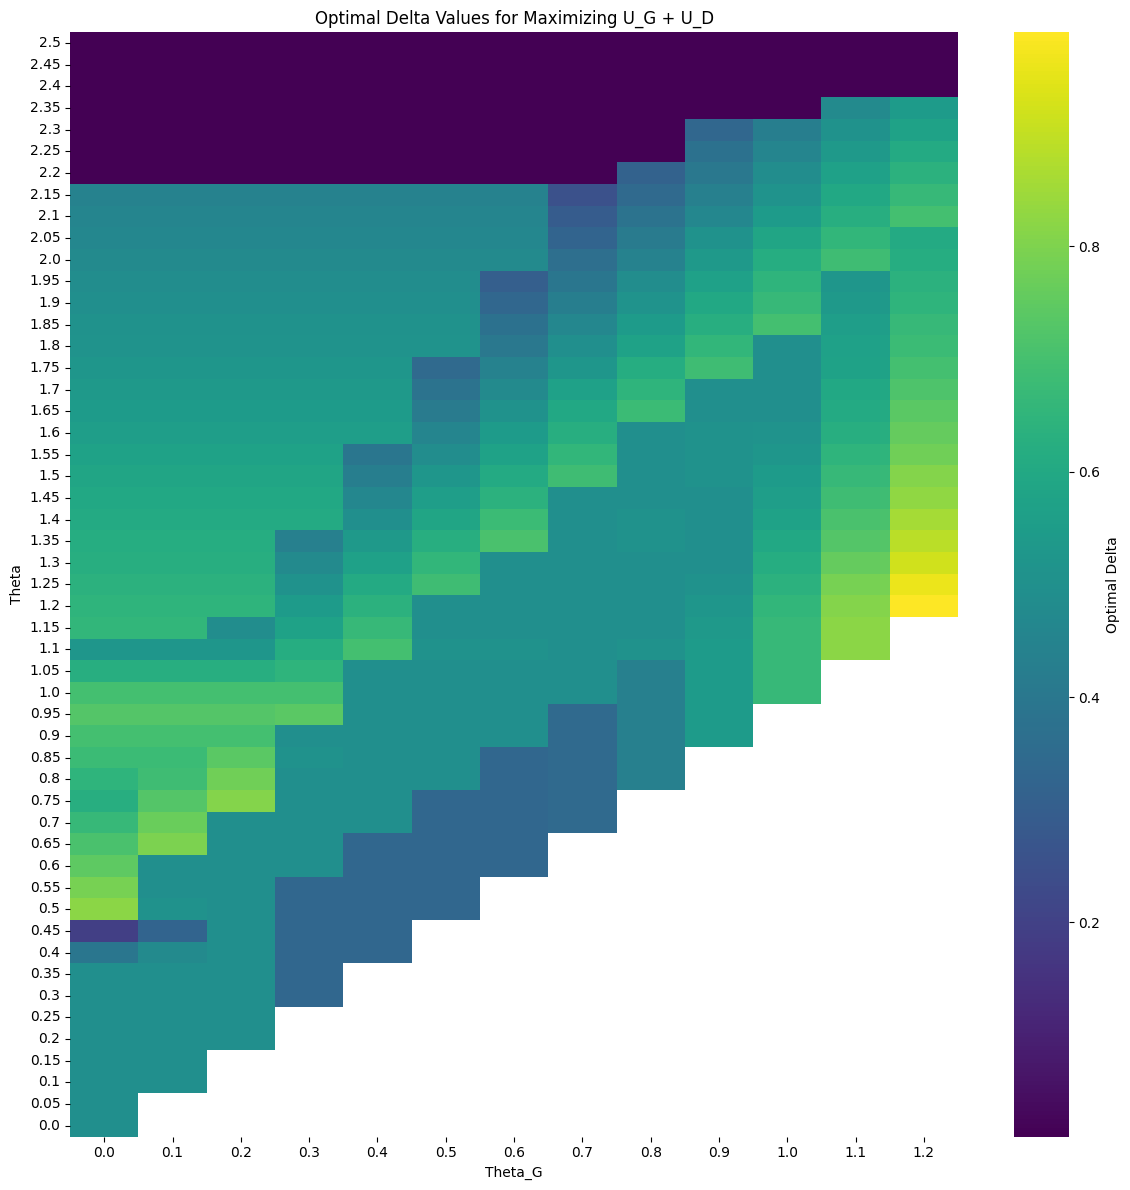

In [35]:
# Create U_util column
results_with_bargaining_old['U_util'] = results_with_bargaining_old['U_G'] + results_with_bargaining_old['U_D']

#Round the results_with_bargaining_old dataframe theta and thetaG to 3 decimal places
results_with_bargaining_old['theta'] = results_with_bargaining_old['theta'].round(3)
results_with_bargaining_old['thetaG'] = results_with_bargaining_old['thetaG'].round(3)

# For every combination of theta and theta_G, find the delta that maximizes U_util
optimal_deltas = results_with_bargaining_old.groupby(['theta', 'thetaG']).apply(
    lambda group: group.loc[group['U_util'].idxmax()]
).reset_index(drop=True)

print(f"Found {len(optimal_deltas)} optimal delta combinations")
print(optimal_deltas[['theta', 'thetaG', 'delta', 'U_util']].head())

# Create a pivot table for visualization
delta_pivot = optimal_deltas.pivot(index='theta', columns='thetaG', values='delta')

# Create the visualization
plt.figure(figsize=(12, 12))
#sns.heatmap(delta_pivot, cmap='viridis', annot=True, fmt='.3f', cbar_kws={'label': 'Optimal Delta'})

# The size of the heatmap is too small, so we need to increase the size
# Switch the x order
delta_pivot = delta_pivot.reindex(index=delta_pivot.index[::-1])
sns.heatmap(delta_pivot, cmap='viridis', cbar_kws={'label': 'Optimal Delta'})
plt.title('Optimal Delta Values for Maximizing U_G + U_D')
plt.xlabel('Theta_G')
plt.ylabel('Theta')
plt.tight_layout()
plt.show()



In [56]:
# Create more density in the rights spots

#results_with_bargaining = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy'])
#results_with_bargaining['C0']=[None]*10000

#vary between 0.25 and 0.5 for theta, for thetaG values between 0 and 0.5.
theta_Gs = np.linspace(0.05,0.45,6)
deltas = np.linspace(0.01,0.99,98)

theta_Gs = np.linspace(0,0.5,21)
theta_Ds = np.linspace(0.25, 0.5, 11)
print(theta_Gs)
print(theta_Ds)

index = 0
for gt in theta_Gs:
    print("Theta_G: ",gt)
    # iterate t from max(gt,0.25) to 0.45, in increments of 0.01
    for t in theta_Ds:
        print("Theta: ",t)
        if gt>t:
            print("Skipping because gt>t")
            continue
        if gt % 0.1 == 0 and np.round(t*20,4) % 1 == 0:
            print("Skipping because gt % 0.1 == 0 and t % 0.05 == 0")
            continue
        for d in deltas:
            if d==0.5:
                print("Delta: ",d)
            gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,d,t,gt)
            gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,d,t)
            alpha_0 = gamma_0[0]
            beta_0 = gamma_0[1]
            alpha_1 = gamma_1[0]
            beta_1 = gamma_1[1]
            results_with_bargaining.at[index,'C0']=str(C_0)
            results_with_bargaining.at[index,'C1']=str(C_1)
            results_with_bargaining.at[index,'r']=str(r)
            results_with_bargaining.at[index,'delta']=d
            results_with_bargaining.at[index,'theta']=t
            results_with_bargaining.at[index,'thetaG']=gt
            results_with_bargaining.at[index,'alpha_0']=float(alpha_0)
            results_with_bargaining.at[index,'beta_0']=float(beta_0)
            results_with_bargaining.at[index,'alpha_1']=float(alpha_1)
            results_with_bargaining.at[index,'beta_1']=float(beta_1)
            results_with_bargaining.at[index,'U_G']=float(UG)
            results_with_bargaining.at[index,'U_D']=float(UD)
            results_with_bargaining.at[index,'Gstrategy']=strategyG
            results_with_bargaining.at[index,'Dstrategy']=strategyD
            index = index + 1
        results_with_bargaining.to_csv('multi_dimension_with_bargaining_data_extradensity_regions_jun3.csv')



[0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5  ]
[0.25  0.275 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5  ]
Theta_G:  0.0
Theta:  0.25
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta:  0.275
Theta:  0.3
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta:  0.325
Theta:  0.35
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta:  0.375
Theta:  0.4
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta:  0.42500000000000004
Theta:  0.45
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta:  0.475
Theta:  0.5
Skipping because gt % 0.1 == 0 and t % 0.05 == 0
Theta_G:  0.025
Theta:  0.25
Theta:  0.275
Theta:  0.3
Theta:  0.325
Theta:  0.35
Theta:  0.375
Theta:  0.4
Theta:  0.42500000000000004
Theta:  0.45
Theta:  0.475
Theta:  0.5
Theta_G:  0.05
Theta:  0.25
Theta:  0.275
Theta:  0.3
Theta:  0.325
Theta:  0.35


KeyboardInterrupt: 

In [55]:
print(0.25 % 0.01)


0.009999999999999995


# Cycle through theta_G, theta_D, and delta

In [15]:
thetaGs = np.linspace(0,1.2,13)
deltas = [0.00001, 0.0001, 0.001, 0.01] + list(np.linspace(0.02,.98,49)) + [0.99, 0.999, 0.9999, 0.99999]
thetaGs = np.array(thetaGs).astype(float)
deltas = np.array(deltas).astype(float)
print(deltas)

results_with_bargaining = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy'])
results_with_bargaining['C0']=[None]*10000

index = 0
for gt in thetaGs:
    print("Theta_G: ",gt)
    # iterate t+0.005 over gt to 1.505, in increments of 0.1
    for t in np.linspace(gt+0.005,1.505,int(np.round((1.505-gt-0.005)*10))+1):
        print("Theta: ",t)

        # We wish to do an optimization over delta. Our goal is to maximize the sum of utilities U_G + U_D, subject to the constraint that U_G >= 0 and U_D >= 0.
        # We will use a solver to do this.
        # Delta can be any rational number between 0 and 1. The objective is U_G + U_D.
        # We will use a solver to do this.
        # Define objective function for optimization
        def objective(delta_val):
            # Calculate strategies and utilities for given delta
            gamma_0, UG, strategyG = G_strategy(C_0, C_1, r, delta_val, t, gt)
            gamma_1, UD, strategyD = D_strategy(gamma_0, C_1, r, delta_val, t)
            
            # Return negative sum since we want to maximize
            return -(UG + UD)
        
        # Define constraint functions
        def constraint_UG(delta_val):
            gamma_0, UG, strategyG = G_strategy(C_0, C_1, r, delta_val, t, gt)
            return UG  # UG >= 0
        
        def constraint_UD(delta_val):
            gamma_0, UG, strategyG = G_strategy(C_0, C_1, r, delta_val, t, gt)
            gamma_1, UD, strategyD = D_strategy(gamma_0, C_1, r, delta_val, t)
            return UD  # UD >= 0
        
        # Set up constraints
        constraints = [
            {'type': 'ineq', 'fun': constraint_UG},
            {'type': 'ineq', 'fun': constraint_UD}
        ]
        
        # Bounds for delta (between 0 and 1)
        bounds = [(0.0001, 0.9999)]
        
        # Initial guess
        initial_guess = [0.5]
        
        # Solve optimization problem
        from scipy.optimize import minimize

        #Avoiding the following error: ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.        
        result = minimize(objective, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        
        # Extract optimal delta
        delta = result.x[0] if result.success else 0.5

        print("Delta: ",delta)

        # Calculate the utilities
        gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,delta,t,gt)
        gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,delta,t)
        alpha_0 = gamma_0[0]
        beta_0 = gamma_0[1]
        alpha_1 = gamma_1[0]
        beta_1 = gamma_1[1]
        results_with_bargaining.at[index,'C0']=str(C_0)
        results_with_bargaining.at[index,'C1']=str(C_1)
        results_with_bargaining.at[index,'r']=str(r)
        results_with_bargaining.at[index,'delta']=delta
        results_with_bargaining.at[index,'theta']=t
        results_with_bargaining.at[index,'thetaG']=gt
        results_with_bargaining.at[index,'alpha_0']=float(alpha_0)
        results_with_bargaining.at[index,'beta_0']=float(beta_0)
        results_with_bargaining.at[index,'alpha_1']=float(alpha_1)
        results_with_bargaining.at[index,'beta_1']=float(beta_1)
        results_with_bargaining.at[index,'U_G']=float(UG)
        results_with_bargaining.at[index,'U_D']=float(UD)
        results_with_bargaining.at[index,'Gstrategy']=strategyG
        results_with_bargaining.at[index,'Dstrategy']=strategyD
        index = index + 1



[1.0000e-05 1.0000e-04 1.0000e-03 1.0000e-02 2.0000e-02 4.0000e-02
 6.0000e-02 8.0000e-02 1.0000e-01 1.2000e-01 1.4000e-01 1.6000e-01
 1.8000e-01 2.0000e-01 2.2000e-01 2.4000e-01 2.6000e-01 2.8000e-01
 3.0000e-01 3.2000e-01 3.4000e-01 3.6000e-01 3.8000e-01 4.0000e-01
 4.2000e-01 4.4000e-01 4.6000e-01 4.8000e-01 5.0000e-01 5.2000e-01
 5.4000e-01 5.6000e-01 5.8000e-01 6.0000e-01 6.2000e-01 6.4000e-01
 6.6000e-01 6.8000e-01 7.0000e-01 7.2000e-01 7.4000e-01 7.6000e-01
 7.8000e-01 8.0000e-01 8.2000e-01 8.4000e-01 8.6000e-01 8.8000e-01
 9.0000e-01 9.2000e-01 9.4000e-01 9.6000e-01 9.8000e-01 9.9000e-01
 9.9900e-01 9.9990e-01 9.9999e-01]
Theta_G:  0.0
Theta:  0.005


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [21]:
#Instead of looping as above, apply a vectorized approach using lambda functions

# Define the lambda functions
G_strategy_vec = lambda C_0, C_1, r, d, t, gt: G_strategy(C_0, C_1, r, d, t, gt)
D_strategy_vec = lambda gamma_0, C_1, r, d, t: D_strategy(gamma_0, C_1, r, d, t)

# Create a grid of parameters
thetaGs = np.linspace(0,1.2,13)
deltas = np.linspace(0.01,.99,98)
thetaDs = np.linspace(0,2.5,26)
grid = np.meshgrid(thetaGs,deltas,thetaDs)

# For every combination of thetaG, delta, and thetaD, calculate the optimal strategies using the lambda functions   
results_with_bargaining['Gstrategy'] = str([G_strategy_vec(C_0,C_1,r,deltas,grid[2].flatten(),grid[0].flatten())])
results_with_bargaining['Dstrategy'] = str([D_strategy_vec(results_with_bargaining['Gstrategy'],C_1,r,deltas,grid[2].flatten())])

ValueError: operands could not be broadcast together with shapes (98,) (2,) 

In [1172]:
thetaGs = np.linspace(0,1,51)
deltas = np.linspace(0.01,.99,98)

#results_with_bargaining = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy'])
#results_with_bargaining['C0']=[None]*10000

index = 0
for gt in thetaGs:
    print("Theta_G: ",gt)
    for t in np.linspace(gt,2.5,int(np.round((2.5-gt)*20))+1):
        print("Theta: ",t)
        for d in deltas:
            #print(np.round(d,6))
            gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,d,t,gt)
            gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,d,t)
            #if UG==-.1 or UD==-.1:
            #    infeasible_flag=1
            alpha_0 = gamma_0[0]
            beta_0 = gamma_0[1]
            alpha_1 = gamma_1[0]
            beta_1 = gamma_1[1]
            results_with_bargaining.at[index,'C0']=str(C_0)
            results_with_bargaining.at[index,'C1']=str(C_1)
            results_with_bargaining.at[index,'r']=str(r)
            results_with_bargaining.at[index,'delta']=d
            results_with_bargaining.at[index,'theta']=t
            results_with_bargaining.at[index,'thetaG']=gt
            results_with_bargaining.at[index,'alpha_0']=float(alpha_0)
            results_with_bargaining.at[index,'beta_0']=float(beta_0)
            results_with_bargaining.at[index,'alpha_1']=float(alpha_1)
            results_with_bargaining.at[index,'beta_1']=float(beta_1)
            results_with_bargaining.at[index,'U_G']=float(UG)
            results_with_bargaining.at[index,'U_D']=float(UD)
            results_with_bargaining.at[index,'Gstrategy']=strategyG
            results_with_bargaining.at[index,'Dstrategy']=strategyD
            index = index + 1
    results_with_bargaining.to_csv('multi_dimension_with_bargaining_data_jun3.csv')


Theta_G:  0.0
Theta:  0.0
Theta:  0.05
Theta:  0.1
Theta:  0.15000000000000002
Theta:  0.2
Theta:  0.25
Theta:  0.30000000000000004
Theta:  0.35000000000000003
Theta:  0.4
Theta:  0.45
Theta:  0.5
Theta:  0.55
Theta:  0.6000000000000001
Theta:  0.65
Theta:  0.7000000000000001
Theta:  0.75
Theta:  0.8
Theta:  0.8500000000000001
Theta:  0.9
Theta:  0.9500000000000001
Theta:  1.0
Theta:  1.05
Theta:  1.1
Theta:  1.1500000000000001
Theta:  1.2000000000000002
Theta:  1.25
Theta:  1.3
Theta:  1.35
Theta:  1.4000000000000001
Theta:  1.4500000000000002
Theta:  1.5
Theta:  1.55
Theta:  1.6
Theta:  1.6500000000000001
Theta:  1.7000000000000002
Theta:  1.75
Theta:  1.8
Theta:  1.85
Theta:  1.9000000000000001
Theta:  1.9500000000000002
Theta:  2.0
Theta:  2.0500000000000003
Theta:  2.1
Theta:  2.15
Theta:  2.2
Theta:  2.25
Theta:  2.3000000000000003
Theta:  2.35
Theta:  2.4000000000000004
Theta:  2.45
Theta:  2.5
Theta_G:  0.09999999999999999
Theta:  0.09999999999999999
Theta:  0.15
Theta:  0.1999

Theta:  2.0999999999999996
Theta:  2.15
Theta:  2.2
Theta:  2.25
Theta:  2.3
Theta:  2.3499999999999996
Theta:  2.4
Theta:  2.45
Theta:  2.5
Theta_G:  1.2
Theta:  1.2
Theta:  1.25
Theta:  1.3
Theta:  1.35
Theta:  1.4
Theta:  1.45
Theta:  1.5
Theta:  1.55
Theta:  1.6
Theta:  1.65
Theta:  1.7
Theta:  1.75
Theta:  1.8
Theta:  1.85
Theta:  1.9
Theta:  1.95
Theta:  2.0
Theta:  2.05
Theta:  2.1
Theta:  2.15
Theta:  2.2
Theta:  2.25
Theta:  2.3
Theta:  2.35
Theta:  2.4000000000000004
Theta:  2.45
Theta:  2.5


In [1173]:
results_with_bargaining.to_csv('multi_dimension_with_bargaining_data_jun3.csv')

In [868]:
np.round((2.5-1.1)*10)

In [1731]:
49686/13*98

In [1282]:
results_with_bargaining['nash'] = results_with_bargaining['U_G'] * results_with_bargaining['U_D'] + 0.000001*(results_with_bargaining['U_G'] + results_with_bargaining['U_D'])
results_with_bargaining['utilitarian'] = results_with_bargaining['U_G'] + results_with_bargaining['U_D'] + 0.0001*results_with_bargaining['nash']
results_with_bargaining['egalitarian'] = np.minimum(results_with_bargaining['U_G'], results_with_bargaining['U_D'])



In [1283]:
joint_utility_maxima = results_with_bargaining.groupby(['thetaG','theta']).max()[['U_G','U_D','utilitarian','nash','egalitarian']]

results_bargained = pd.merge(results_with_bargaining, joint_utility_maxima, on = ['thetaG','theta'],suffixes=('','_max'))

results_bargained


,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian,U_G_max,U_D_max,utilitarian_max,nash_max,egalitarian_max
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.01,0.0,0.0,0.005,0.5,0.5,0.00995,0.49995,unconstrained,unconstrained,0.005000,0.5099,0.004975,0.00995,0.454099,0.49995,0.749989,0.14061,0.372461
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.020103,0.0,0.0,0.010052,0.5,0.5,0.019901,0.499798,unconstrained,unconstrained,0.010052,0.5197,0.009947,0.019901,0.454099,0.49995,0.749989,0.14061,0.372461
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.030206,0.0,0.0,0.015103,0.5,0.5,0.02975,0.499544,unconstrained,unconstrained,0.015103,0.529295,0.014862,0.02975,0.454099,0.49995,0.749989,0.14061,0.372461
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.040309,0.0,0.0,0.020155,0.5,0.5,0.039497,0.499188,unconstrained,unconstrained,0.020155,0.538686,0.019717,0.039497,0.454099,0.49995,0.749989,0.14061,0.372461
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.050412,0.0,0.0,0.025206,0.5,0.5,0.049142,0.498729,unconstrained,unconstrained,0.025206,0.547873,0.024509,0.049142,0.454099,0.49995,0.749989,0.14061,0.372461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49681,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.949588,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.199999,0.01,-0.1,-0.100000,-0.10000,-0.199999,0.01000,-0.100000
49682,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.959691,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.199999,0.01,-0.1,-0.100000,-0.10000,-0.199999,0.01000,-0.100000
49683,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.969794,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.199999,0.01,-0.1,-0.100000,-0.10000,-0.199999,0.01000,-0.100000
49684,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.979897,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.199999,0.01,-0.1,-0.100000,-0.10000,-0.199999,0.01000,-0.100000


In [1296]:
results_utilitarian = results_bargained[results_bargained['egalitarian']==results_bargained['egalitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)
#results_utilitarian

In [1297]:
results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1
        

In [1298]:
#Backfiring example
gamma_0_bex, UG_bex, strategyG_bex = G_strategy(C_0,C_1,r=np.array([1,1]),delta=0.5,theta=0.,thetaG=0)
gamma_1_bex, UD_bex, strategyD_bex = D_strategy(gamma_0_bex,C_1,r=np.array([1,1]),delta=0.5,theta=0.)
print(gamma_0, UG, strategyG)
print(gamma_1, UD, strategyD)


[-0.1 -0.1] -0.1 abstain
[-0.1 -0.1] -0.1 abstain


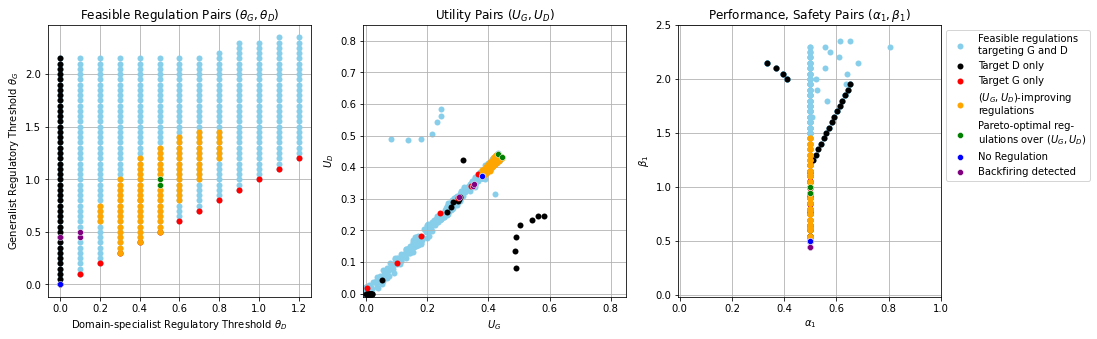

In [1307]:
fix,ax = plt.subplots(1,3,figsize=[16,5])

sns.scatterplot(data=results_utilitarian[results_utilitarian['U_D']>=0],x='thetaG',y='theta',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[0],zorder=5)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='thetaG',y='theta',color='black',alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='thetaG',y='theta',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,ax=ax[0],zorder=5)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='thetaG',y='theta',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='thetaG',y='theta',color='green',alpha=1#,label='Pareto-opt improvement'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='thetaG',y='theta',color='blue',alpha=1#,label='Anarchy'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='thetaG',y='theta',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[0],zorder=10)
ax[0].set_xlabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_ylabel("Generalist Regulatory Threshold $\\theta_G$")
ax[0].grid(zorder=-10)
ax[0].set_title("Feasible Regulation Pairs $(\\theta_G,\\theta_D)$")
#ax[0].legend(loc='upper left')
#ax[0].set_ylim([-0.01,1.85])
#ax[0].set_xlim([-0.013,2.5])

ax[1].grid(zorder=-10)
sns.scatterplot(data=results_utilitarian,x='U_D',y='U_G',color='skyblue',linewidth=0#,label='Regulate Both'
                ,ax=ax[1])
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color='black',linewidth=0,alpha=1#,label='Regulate D'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='U_G',y='U_D',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='U_G',y='U_D',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='U_G',y='U_D',color='green',alpha=1#,label='Pareto-opt improvement'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.1)&(results_utilitarian['thetaG']<0.1)],x='U_G',y='U_D',color='blue',alpha=1#,label='Anarchy'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='U_G',y='U_D',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[1],zorder=6)
ax[1].set_xlim([-0.01,.85])
ax[1].set_ylim([-0.01,.85])
ax[1].set_title("Utility Pairs $(U_G,U_D)$")
ax[1].set_xlabel('$U_G$')
ax[1].set_ylabel('$U_D$')

sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)],x='alpha_1',y='beta_1',color='skyblue',label='Feasible regulations \ntargeting G and D',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='alpha_1',y='beta_1',color='black',alpha=1,label='Target D only',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='alpha_1',y='beta_1',color='red',alpha=1,label='Target G only',linewidth=0,ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[results_utilitarian['U_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='orange',alpha=1,ax=ax[2],linewidth=0,label='$(U_G,U_D)$-improving \nregulations',zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto-optimal reg-\nulations over $(U_G, U_D)$',ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.1)&(results_utilitarian['thetaG']<0.1)],x='alpha_1',y='beta_1',color='blue',alpha=1,label='No Regulation',ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='alpha_1',y='beta_1',color='purple'
                ,alpha=1,label='Backfiring detected'
                ,ax=ax[2],zorder=7)
ax[2].grid()
ax[2].set_xlim([-0.005,1])
ax[2].set_ylim([-0.015,2.5])
ax[2].set_title("Performance, Safety Pairs $(\\alpha_1,\\beta_1)$")
ax[2].set_xlabel('$\\alpha_1$')
ax[2].set_ylabel('$\\beta_1$')
ax[2].legend(bbox_to_anchor=[1,1])

plt.savefig('multivariate_analysis_pareto_regulation_withbargaining_egalitarian_jun3.png',bbox_inches='tight',dpi=200)


In [1300]:
results_one_attribute = results_with_bargaining.copy()
results_one_attribute['utilitarian'] = np.add(results_one_attribute['U_G'].astype(float) , results_one_attribute['U_D'].astype(float))
results_one_attribute['utilitarian'] = results_one_attribute['utilitarian'].astype(float)
results_one_attribute['nash'] = -.1
results_one_attribute.loc[results_one_attribute['utilitarian']>=0,'nash'] = np.multiply(results_one_attribute.loc[results_one_attribute['utilitarian']>=0,'U_G'] , (results_one_attribute.loc[results_one_attribute['utilitarian']>=0,'U_D']))
results_one_attribute['nash'] = results_one_attribute['nash'].astype(float)
results_one_attribute['egalitarian'] = np.minimum(results_one_attribute['U_G'], results_one_attribute['U_D'])
results_one_attribute['egalitarian'] = results_one_attribute['egalitarian'].astype(float)

#slight change to utilitarian to tie-break using nash
results_one_attribute['utilitarian'] = np.add(results_one_attribute['utilitarian'] , 0.00001*results_one_attribute['nash'] )

results_one_attribute['thetaG']=results_one_attribute['thetaG'].astype(float)
results_one_attribute['theta']=results_one_attribute['theta'].astype(float)

joint_utility_maxima = results_one_attribute.groupby(['thetaG','theta']).max()[['U_G','U_D','utilitarian','nash','egalitarian']].reset_index()

joint_utility_maxima['thetaG']=joint_utility_maxima['thetaG'].astype(float)
joint_utility_maxima['theta']=joint_utility_maxima['theta'].astype(float)
results_bargained = pd.merge(results_one_attribute, joint_utility_maxima, on = ['thetaG','theta'],suffixes=('','_max'))
results_bargained

,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian,U_G_max,U_D_max,utilitarian_max,nash_max,egalitarian_max
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.01,0.0,0.0,0.005,0.5,0.5,0.00995,0.49995,unconstrained,unconstrained,0.005000,0.509900,0.004975,0.009950,0.454099,0.49995,0.749976,0.140609,0.372461
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.020103,0.0,0.0,0.010052,0.5,0.5,0.019901,0.499798,unconstrained,unconstrained,0.010052,0.519699,0.009946,0.019901,0.454099,0.49995,0.749976,0.140609,0.372461
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.030206,0.0,0.0,0.015103,0.5,0.5,0.02975,0.499544,unconstrained,unconstrained,0.015103,0.529294,0.014861,0.029750,0.454099,0.49995,0.749976,0.140609,0.372461
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.040309,0.0,0.0,0.020155,0.5,0.5,0.039497,0.499188,unconstrained,unconstrained,0.020155,0.538685,0.019716,0.039497,0.454099,0.49995,0.749976,0.140609,0.372461
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.050412,0.0,0.0,0.025206,0.5,0.5,0.049142,0.498729,unconstrained,unconstrained,0.025206,0.547871,0.024508,0.049142,0.454099,0.49995,0.749976,0.140609,0.372461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49681,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.949588,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.200001,-0.100000,-0.100000,-0.100000,-0.10000,-0.200001,-0.100000,-0.100000
49682,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.959691,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.200001,-0.100000,-0.100000,-0.100000,-0.10000,-0.200001,-0.100000,-0.100000
49683,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.969794,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.200001,-0.100000,-0.100000,-0.100000,-0.10000,-0.200001,-0.100000,-0.100000
49684,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.979897,2.5,1.2,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,-0.100000,-0.200001,-0.100000,-0.100000,-0.100000,-0.10000,-0.200001,-0.100000,-0.100000


In [1308]:
results_utilitarian = results_bargained[results_bargained['nash']==results_bargained['nash_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1
        

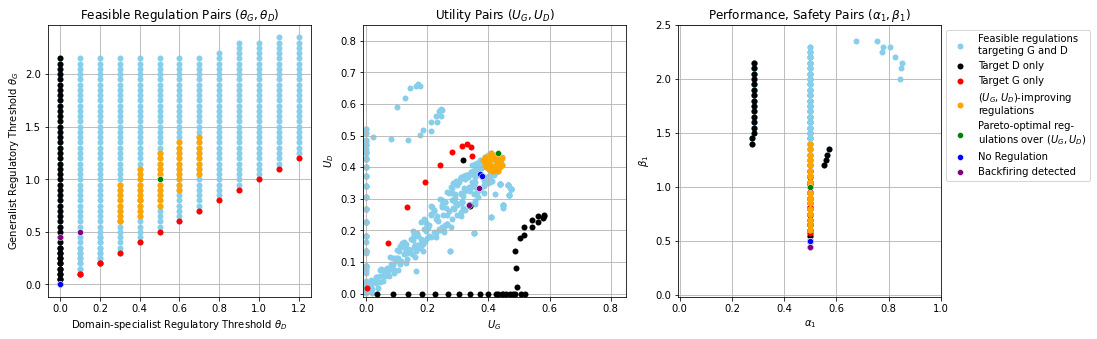

In [1309]:
fix,ax = plt.subplots(1,3,figsize=[16,5])

sns.scatterplot(data=results_utilitarian[results_utilitarian['U_D']>=0],x='thetaG',y='theta',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[0],zorder=5)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='thetaG',y='theta',color='black',alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='thetaG',y='theta',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,ax=ax[0],zorder=5)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='thetaG',y='theta',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='thetaG',y='theta',color='green',alpha=1#,label='Pareto-opt improvement'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='thetaG',y='theta',color='blue',alpha=1#,label='Anarchy'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='thetaG',y='theta',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[0],zorder=10)
ax[0].set_xlabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_ylabel("Generalist Regulatory Threshold $\\theta_G$")
ax[0].grid(zorder=-10)
ax[0].set_title("Feasible Regulation Pairs $(\\theta_G,\\theta_D)$")
#ax[0].legend(loc='upper left')
#ax[0].set_ylim([-0.01,1.85])
#ax[0].set_xlim([-0.013,2.5])

ax[1].grid(zorder=-10)
sns.scatterplot(data=results_utilitarian,x='U_D',y='U_G',color='skyblue',linewidth=0#,label='Regulate Both'
                ,ax=ax[1])
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color='black',linewidth=0,alpha=1#,label='Regulate D'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='U_G',y='U_D',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='U_G',y='U_D',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='U_G',y='U_D',color='green',alpha=1#,label='Pareto-opt improvement'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.1)&(results_utilitarian['thetaG']<0.1)],x='U_G',y='U_D',color='blue',alpha=1#,label='Anarchy'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='U_G',y='U_D',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[1],zorder=6)
ax[1].set_xlim([-0.01,.85])
ax[1].set_ylim([-0.01,.85])
ax[1].set_title("Utility Pairs $(U_G,U_D)$")
ax[1].set_xlabel('$U_G$')
ax[1].set_ylabel('$U_D$')

sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)],x='alpha_1',y='beta_1',color='skyblue',label='Feasible regulations \ntargeting G and D',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='alpha_1',y='beta_1',color='black',alpha=1,label='Target D only',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='alpha_1',y='beta_1',color='red',alpha=1,label='Target G only',linewidth=0,ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[results_utilitarian['U_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='orange',alpha=1,ax=ax[2],linewidth=0,label='$(U_G,U_D)$-improving \nregulations',zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto-optimal reg-\nulations over $(U_G, U_D)$',ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.1)&(results_utilitarian['thetaG']<0.1)],x='alpha_1',y='beta_1',color='blue',alpha=1,label='No Regulation',ax=ax[2],zorder=8)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='alpha_1',y='beta_1',color='purple'
                ,alpha=1,label='Backfiring detected'
                ,ax=ax[2],zorder=7)
ax[2].grid()
ax[2].set_xlim([-0.005,1])
ax[2].set_ylim([-0.015,2.5])
ax[2].set_title("Performance, Safety Pairs $(\\alpha_1,\\beta_1)$")
ax[2].set_xlabel('$\\alpha_1$')
ax[2].set_ylabel('$\\beta_1$')
ax[2].legend(bbox_to_anchor=[1,1])




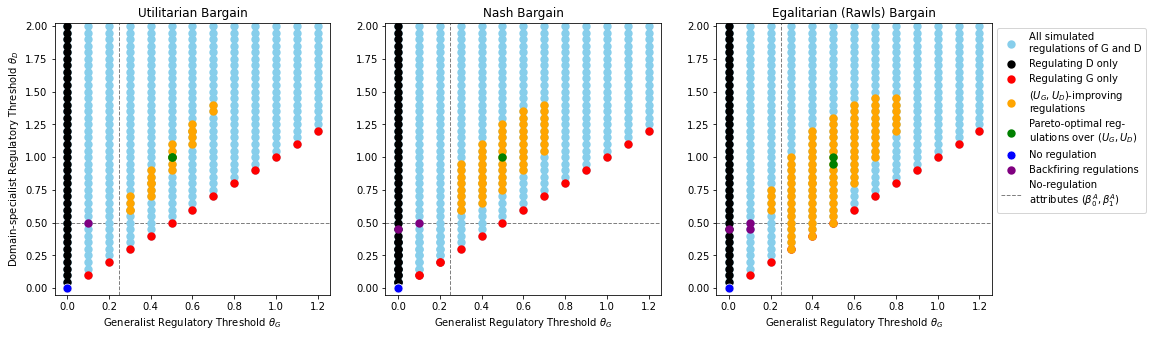

In [1438]:
# Plot different bargains
sns.set_palette("bright")

fix,ax = plt.subplots(1,3,figsize=[16.8,5])


results_utilitarian = results_bargained[results_bargained['utilitarian']==results_bargained['utilitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1
       
    
sizenum=280
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='thetaG',y='theta',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[0],zorder=-5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='thetaG',y='theta',color='black',alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='thetaG',y='theta',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[0],zorder=5,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='thetaG',y='theta',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='thetaG',y='theta',color='green',alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[0],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='thetaG',y='theta',color='blue',alpha=1,s=80#,label='Anarchy'
                ,ax=ax[0],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='thetaG',y='theta',color='purple',alpha=1#,label='Back-firing'
                ,ax=ax[0],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[0].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_xlabel("Generalist Regulatory Threshold $\\theta_G$")
#ax[0].grid(zorder=-10)
ax[0].set_title("Utilitarian Bargain")
#ax[0].legend(loc='upper left')
#ax[0].set_ylim([-0.01,1.85])
ax[0].set_ylim([-0.05,2.0225])
ax[0].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[0].axvline(0.25, linewidth=1, zorder=-10,color='gray',linestyle='--')


results_utilitarian = results_bargained[results_bargained['nash']==results_bargained['nash_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='thetaG',y='theta',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[1],zorder=-5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='thetaG',y='theta',color="black"
                ,alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='thetaG',y='theta',color='red'
                ,linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[1],zorder=5,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='thetaG',y='theta',color="orange"
                ,linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='thetaG',y='theta',color='green'
                ,alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[1],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='thetaG',y='theta',color='blue'
                ,alpha=1,s=80#,label='Anarchy'
                ,ax=ax[1],zorder=6)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='thetaG',y='theta',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[1],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[1].set_ylabel("")
#ax[1].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[1].set_xlabel("Generalist Regulatory Threshold $\\theta_G$")
#ax[1].grid(zorder=-10)
ax[1].set_title("Nash Bargain")
#ax[1].legend(loc='upper left')
ax[1].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[1].axvline(0.25, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[1].set_ylim([-0.05,2.0225])



results_utilitarian = results_bargained[results_bargained['egalitarian']==results_bargained['egalitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<2.21)],x='thetaG',y='theta',color='skyblue'
                ,label='All simulated \nregulations of G and D',linewidth=0,ax=ax[2],zorder=-5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='thetaG',y='theta',color='black'
                ,alpha=1,linewidth=0,label='Regulating D only',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='thetaG',y='theta',color='red'
                ,linewidth=0,alpha=1,label='Regulating G only',marker='.',ax=ax[2],zorder=5,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='thetaG',y='theta',color='orange'
                ,linewidth=0,alpha=1,label='$(U_G,U_D)$-improving \nregulations',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='thetaG',y='theta',color='green'
                ,alpha=1,label='Pareto-optimal reg-\nulations over $(U_G, U_D)$',ax=ax[2],zorder=6,marker='.',linewidth=0,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='thetaG',y='theta',color='blue'
                ,alpha=1,label='No regulation',ax=ax[2],zorder=6,s=80)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='thetaG',y='theta',color='purple'
                ,alpha=1,label='Backfiring regulations',ax=ax[2],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[2].set_ylabel("")
#ax[2].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[2].set_xlabel("Generalist Regulatory Threshold $\\theta_G$")
#ax[2].grid(zorder=-10)
ax[2].set_title("Egalitarian (Rawls) Bargain")
ax[2].set_ylim([-0.05,2.0225])
ax[2].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[2].axvline(0.25, linewidth=1, zorder=-10,color='gray',linestyle='--',label='No-regulation\nattributes ($\\beta_0^A,\\beta_1^A$)')

ax[2].legend(bbox_to_anchor=[1,1])

plt.savefig('multivariate_analysis_reg_map_jun3.png',bbox_inches='tight',dpi=200)


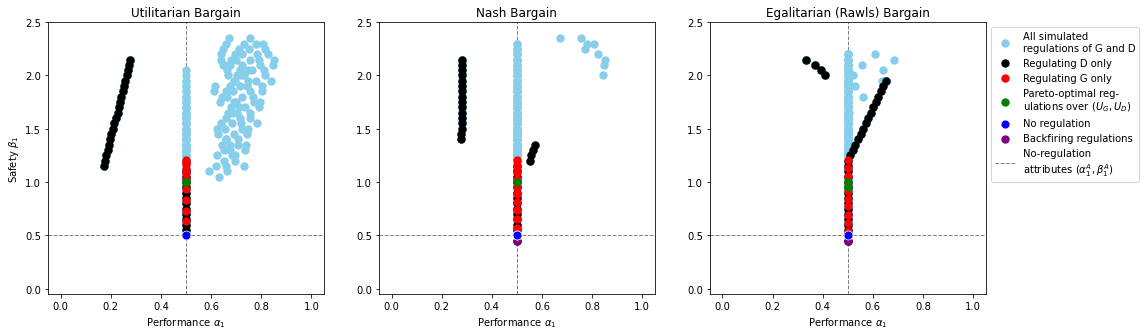

In [1435]:
# Plot different bargains
sns.set_palette("bright")

fix,ax = plt.subplots(1,3,figsize=[16.8,5])


results_utilitarian = results_bargained[results_bargained['utilitarian']==results_bargained['utilitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1
       
    
sizenum=280
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='alpha_1',y='beta_1',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[0],zorder=5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='alpha_1',y='beta_1',color='black',alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='alpha_1',y='beta_1',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[0],zorder=6,s=sizenum)
#sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
#                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green',alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[0],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='alpha_1',y='beta_1',color='blue',alpha=1,s=80#,label='Anarchy'
                ,ax=ax[0],zorder=60)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='alpha_1',y='beta_1',color='purple',alpha=1#,label='Back-firing'
                ,ax=ax[0],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[0].set_ylabel("Safety $\\beta_1$")
ax[0].set_xlabel("Performance $\\alpha_1$")
#ax[0].grid(zorder=-10)
ax[0].set_title("Utilitarian Bargain")
#ax[0].legend(loc='upper left')
#ax[0].set_ylim([-0.01,1.85])
ax[0].set_xlim([-0.05,1.05])
ax[0].set_ylim([-0.05,2.5])
ax[0].axvline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[0].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')


results_utilitarian = results_bargained[results_bargained['nash']==results_bargained['nash_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='alpha_1',y='beta_1',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[1],zorder=5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='alpha_1',y='beta_1',color="black"
                ,alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='alpha_1',y='beta_1',color='red'
                ,linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[1],zorder=6,s=sizenum)
#sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color="orange"
#                ,linewidth=0,alpha=1#,label='All util-improving regs'
#                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green'
                ,alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[1],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='alpha_1',y='beta_1',color='blue'
                ,alpha=1,s=80#,label='Anarchy'
                ,ax=ax[1],zorder=60)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='alpha_1',y='beta_1',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[1],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[1].set_ylabel("")
#ax[1].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[1].set_xlabel("Performance $\\alpha_1$")
#ax[1].grid(zorder=-10)
ax[1].set_title("Nash Bargain")
#ax[1].legend(loc='upper left')
ax[1].axvline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[1].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[1].set_xlim([-0.05,1.05])
ax[1].set_ylim([-0.05,2.5])

results_utilitarian = results_bargained[results_bargained['egalitarian']==results_bargained['egalitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<2.21)],x='alpha_1',y='beta_1',color='skyblue'
                ,label='All simulated \nregulations of G and D',linewidth=0,ax=ax[2],zorder=-5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='alpha_1',y='beta_1',color='black'
                ,alpha=1,linewidth=0,label='Regulating D only',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='alpha_1',y='beta_1',color='red'
                ,linewidth=0,alpha=1,label='Regulating G only',marker='.',ax=ax[2],zorder=6,s=sizenum)
#sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='orange'
#                ,linewidth=0,alpha=1,label='$(U_G,U_D)$-improving \nregulations',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green'
                ,alpha=1,label='Pareto-optimal reg-\nulations over $(U_G, U_D)$',ax=ax[2],zorder=6,marker='.',linewidth=0,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='alpha_1',y='beta_1',color='blue'
                ,alpha=1,label='No regulation',ax=ax[2],zorder=80,s=80)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='alpha_1',y='beta_1',color='purple'
                ,alpha=1,label='Backfiring regulations',ax=ax[2],zorder=7,linewidth=0,marker='.',s=sizenum)

ax[2].set_ylabel("")
#ax[2].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[2].set_xlabel("Performance $\\alpha_1$")
#ax[2].grid(zorder=-10)
ax[2].set_title("Egalitarian (Rawls) Bargain")
ax[2].set_xlim([-0.05,1.05])
ax[2].set_ylim([-0.05,2.5])
ax[2].axvline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--')
ax[2].axhline(0.5, linewidth=1, zorder=-10,color='gray',linestyle='--',label='No-regulation\nattributes ($\\alpha_1^A,\\beta_1^A$)')

ax[2].legend(bbox_to_anchor=[1,1])

plt.savefig('multivariate_analysis_performance_safety_map_jun3.png',bbox_inches='tight',dpi=200)

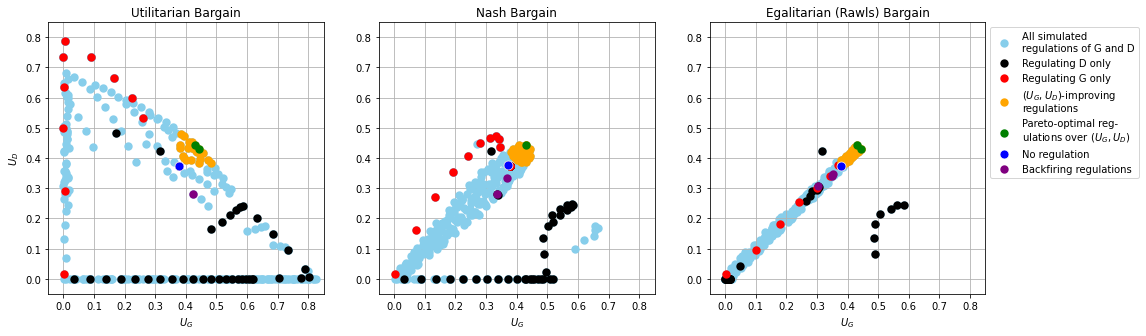

In [1431]:
# Plot different bargains
sns.set_palette("bright")

fix,ax = plt.subplots(1,3,figsize=[16.8,5])


results_utilitarian = results_bargained[results_bargained['utilitarian']==results_bargained['utilitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1
       
    
sizenum=280
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='U_G',y='U_D',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[0],zorder=5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color='black',alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='U_G',y='U_D',color='red',linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[0],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='U_G',y='U_D',color='orange',linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[0],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='U_G',y='U_D',color='green',alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[0],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<0.01)&(results_utilitarian['thetaG']<0.01)],x='U_G',y='U_D',color='blue',alpha=1,s=80#,label='Anarchy'
                ,ax=ax[0],zorder=60)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='U_G',y='U_D',color='purple',alpha=1#,label='Back-firing'
                ,ax=ax[0],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[0].set_ylabel("$U_D$")
ax[0].set_xlabel("$U_G$")
ax[0].grid()
ax[0].set_title("Utilitarian Bargain")
#ax[0].legend(loc='upper left')
ax[0].set_xlim([-0.05,.85])
ax[0].set_ylim([-0.05,.85])
#ax[0].axvline(3/16, linewidth=1, zorder=10,color='gray',linestyle='--')
#ax[0].axhline(3/16, linewidth=1, zorder=10,color='gray',linestyle='--')


results_utilitarian = results_bargained[results_bargained['nash']==results_bargained['nash_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<3)],x='U_G',y='U_D',color='skyblue'#,label='Regulate Both'
                ,linewidth=0,ax=ax[1],zorder=5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color="black"
                ,alpha=1,linewidth=0#,label='Regulate D'
                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='U_G',y='U_D',color='red'
                ,linewidth=0,alpha=1#,label='Regulate G'
                ,marker='.',ax=ax[1],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='U_G',y='U_D',color="orange"
                ,linewidth=0,alpha=1#,label='All util-improving regs'
                ,ax=ax[1],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='U_G',y='U_D',color='green'
                ,alpha=1,marker='.',linewidth=0#,label='Pareto-opt improvement'
                ,ax=ax[1],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian.loc[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']==0)&(results_utilitarian['thetaG']==0)[0:1],:],x='U_G',y='U_D',color='blue'
                ,alpha=1,s=80#,label='Anarchy'
                ,ax=ax[1],zorder=7)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='U_G',y='U_D',color='purple'
                ,alpha=1#,label='Back-firing'
                ,ax=ax[1],zorder=6,linewidth=0,marker='.',s=sizenum)

ax[1].set_ylabel("")
#ax[1].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[1].set_xlabel("$U_G$")
#ax[1].grid(zorder=-10)
ax[1].set_title("Nash Bargain")
#ax[1].legend(loc='upper left')
#ax[1].axvline(0.5, linewidth=1, zorder=10,color='gray',linestyle='--')
#ax[1].axhline(0.5, linewidth=1, zorder=10,color='gray',linestyle='--')
ax[1].set_xlim([-0.05,.85])
ax[1].set_ylim([-0.05,.85])
ax[1].grid()


results_utilitarian = results_bargained[results_bargained['egalitarian']==results_bargained['egalitarian_max']]
results_utilitarian = results_utilitarian.dropna()
results_utilitarian = results_utilitarian.reset_index(drop=True)

results_utilitarian['U_pareto']=0
results_utilitarian['U_pareto_dominates_anarchy']=0
results_utilitarian['U_dominates_anarchy']=0

anarchy_UG = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_G'])
anarchy_UD = np.max(results_utilitarian[(results_utilitarian['theta']<0.05)&(results_utilitarian['thetaG']<0.05)]['U_D'])

for weight in np.linspace(0,1,1001):
    idx = np.argmax(np.add(weight*results_utilitarian['U_G'],(1-weight)*results_utilitarian['U_D']))
    results_utilitarian.loc[idx,'U_pareto']=1
    if results_utilitarian.loc[idx,'U_G']>anarchy_UG and results_utilitarian.loc[idx,'U_D']>anarchy_UD:
        results_utilitarian.loc[idx,'U_pareto_dominates_anarchy']=1
        
for i in range(len(results_utilitarian)):
    if results_utilitarian.loc[i,'U_G']>anarchy_UG and results_utilitarian.loc[i,'U_D']>anarchy_UD:
        results_utilitarian.loc[i,'U_dominates_anarchy']=1

#sizenum=28
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<2.21)],x='U_G',y='U_D',color='skyblue'
                ,label='All simulated \nregulations of G and D',linewidth=0,ax=ax[2],zorder=-5,alpha=1,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color='black'
                ,alpha=1,linewidth=0,label='Regulating D only',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']<=results_utilitarian['thetaG'])],x='U_G',y='U_D',color='red'
                ,linewidth=0,alpha=1,label='Regulating G only',marker='.',ax=ax[2],zorder=6,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_dominates_anarchy']==1)],x='U_G',y='U_D',color='orange'
                ,linewidth=0,alpha=1,label='$(U_G,U_D)$-improving \nregulations',ax=ax[2],zorder=6,marker='.',s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['U_pareto_dominates_anarchy']==1)],x='U_G',y='U_D',color='green'
                ,alpha=1,label='Pareto-optimal reg-\nulations over $(U_G, U_D)$',ax=ax[2],zorder=6,marker='.',linewidth=0,s=sizenum)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['theta']==0.0)&(results_utilitarian['thetaG']==0)],x='U_G',y='U_D',color='blue'
                ,alpha=1,label='No regulation',ax=ax[2],zorder=80,s=80)
sns.scatterplot(data=results_utilitarian[(results_utilitarian['U_D']>=0)&(results_utilitarian['beta_1']<0.5)],x='U_G',y='U_D',color='purple'
                ,alpha=1,label='Backfiring regulations',ax=ax[2],zorder=7,linewidth=0,marker='.',s=sizenum)

ax[2].set_ylabel("")
#ax[2].set_ylabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[2].set_xlabel("$U_G$")
#ax[2].grid(zorder=-10)
ax[2].set_title("Egalitarian (Rawls) Bargain")
ax[2].set_xlim([-0.05,.85])
ax[2].set_ylim([-0.05,.85])
#ax[2].axvline(3/16, linewidth=1, zorder=10,color='gray',linestyle='--')
#ax[2].axhline(0.5, linewidth=1, zorder=10,color='gray',linestyle='--',label='Anarchy performance, \nsafety levels ($\\alpha_1,\\beta_1$)')
ax[2].grid()
ax[2].legend(bbox_to_anchor=[1,1])

plt.savefig('multivariate_analysis_utility_bargains_map_jun3.png',bbox_inches='tight',dpi=200)

In [1531]:
def run_and_print(C_0,C_1,r,delta,eps):
    gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,2*eps,eps)
    print(gamma_0, u_g0, stratGex )
    gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,2*eps)
    print(gamma_1, u_d1, stratGex )


In [1532]:
C_0_canon = np.array([[1,0],[0,1]])
C_1_canon = np.array([[1,0],[0,1]])

C_0_neg = np.array([[1,-.1],[-.1,1]])
C_1_neg = np.array([[1,-.1],[-.1,1]])

C_0_pos = np.array([[1,.1],[.1,1]])
C_1_pos = np.array([[1,.1],[.1,1]])


delta = 0.5
r = np.array([1,1])

eps = 0.
run_and_print(C_0_neg,C_1_neg,r,delta,eps)

eps=0.3
run_and_print(C_0_neg,C_1_neg,r,delta,eps)

eps=0.6
run_and_print(C_0_neg,C_1_neg,r,delta,eps)


[0.27777778 0.27777778] 0.4166666666666667 unconstrained
[0.55555556 0.55555556] 0.4166666666666667 unconstrained
[0.28 0.3 ] 0.42840000000000006 $\beta_0=\theta_G$
[0.56 0.6 ] 0.42840000000000006 $\beta_0=\theta_G$
[0.31 0.6 ] 0.49110000000000004 $\beta_0=\theta_G$
[0.62 1.2 ] 0.4911 $\beta_0=\theta_G$


In [1506]:
C_0_superpos = np.array([[1,2],[2,1]])
C_1_superpos = np.array([[1,2],[2,1]])

beta_0_superposs = []
beta_1_superposs = []
alpha_0_superposs = []
alpha_1_superposs = []

for eps in epss:
    gamma_0, u_g0, stratGex = G_strategy(C_0_superpos,C_1_superpos,r,delta,2*eps,eps)
    gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1_superpos,r,delta,2*eps)
    beta_0_superposs = beta_0_superposs +[gamma_0[1]]
    beta_1_superposs = beta_1_superposs +[gamma_1[1]]
    alpha_0_superposs = alpha_0_superposs +[gamma_0[0]]
    alpha_1_superposs = alpha_1_superposs +[gamma_1[0]]

Strange case: 
[[1 2]
 [2 1]] [[1 2]
 [2 1]] [1 1] 0.5 0.0 0.0
Choice:  [0.   0.25] 0.1875 $\alpha_0=0$
All candidates:  [array([0.08333333, 0.08333333]), array([0.  , 0.25]), array([0.25, 0.  ]), array([0., 0.])]
All utilities:  [0.16666666666666666, 0.1875, 0.1875, 0.125]
All strategies:  ['unconstrained', '$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.  , 0.25]), 0.0625, 'constrained $\\alpha_1=\\alpha_0$')
Strange case: 
[[1 2]
 [2 1]] [[1 2]
 [2 1]] [1 1] 0.5 0.2 0.1
Choice:  [0.   0.25] 0.1875 $\alpha_0=0$
All candidates:  [array([0.  , 0.25]), array([0.05, 0.1 ]), array([0. , 0.1])]
All utilities:  [0.1875, 0.16749999999999998, 0.16499999999999998]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.  , 0.35]), 0.1125, 'unconstrained')
Strange case: 
[[1 2]
 [2 1]] [[1 2]
 [2 1]] [1 1] 0.5 0.4 0.2
Choice:  [0.   0.25] 0.1875 $\alpha_0=0$


Strange case: 
[[1 2]
 [2 1]] [[1 2]
 [2 1]] [1 1] 0.5 1.9 0.95
Choice:  [0.   0.95] 0.04749999999999999 $\alpha_0=0$
All candidates:  [array([0.  , 0.95]), array([0.  , 0.95])]
All utilities:  [0.04749999999999999, 0.04749999999999999]
All strategies:  ['$\\alpha_0=0$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0. , 1.9]), 0.04749999999999999, 'unconstrained')


In [1537]:
C_0_canon = np.array([[1,0],[0,1]])
C_1_canon = np.array([[1,0],[0,1]])

beta_0_canons = []
beta_1_canons = []
alpha_0_canons = []
alpha_1_canons = []

epss = np.linspace(0,1.5,31)
for eps in epss:
    
    gamma_0, u_g0, stratGex = G_strategy(C_0_canon,C_1_canon,r,delta,2*eps,eps)
    gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1_canon,r,delta,2*eps)
    beta_0_canons = beta_0_canons +[gamma_0[1]]
    beta_1_canons = beta_1_canons +[gamma_1[1]]
    alpha_0_canons = alpha_0_canons +[gamma_0[0]]
    alpha_1_canons = alpha_1_canons +[gamma_1[0]]

In [1533]:
C_0_neg = np.array([[1,-.1],[-.1,1]])
C_1_neg = np.array([[1,-.1],[-.1,1]])

C_0_pos = np.array([[1,.1],[.1,1]])
C_1_pos = np.array([[1,.1],[.1,1]])

delta = 0.5
r = np.array([1,1])

beta_0_negs = []
beta_1_negs = []
alpha_0_negs = []
alpha_1_negs = []
beta_0_poss = []
beta_1_poss = []
alpha_0_poss = []
alpha_1_poss = []
epss = np.linspace(0,1.5,31)
for eps in epss:
    print(eps)
    gamma_0, u_g0, stratGex = G_strategy(C_0_neg,C_1_neg,r,delta,2*eps,eps)
    gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1_neg,r,delta,2*eps)
    beta_0_negs = beta_0_negs +[gamma_0[1]]
    beta_1_negs = beta_1_negs +[gamma_1[1]]
    alpha_0_negs = alpha_0_negs +[gamma_0[0]]
    alpha_1_negs = alpha_1_negs +[gamma_1[0]]
    gamma_0, u_g0, stratGex = G_strategy(C_0_pos,C_1_pos,r,delta,2*eps,eps)
    gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1_pos,r,delta,2*eps)
    beta_0_poss = beta_0_poss +[gamma_0[1]]
    beta_1_poss = beta_1_poss +[gamma_1[1]]
    alpha_0_poss = alpha_0_poss +[gamma_0[0]]
    alpha_1_poss = alpha_1_poss +[gamma_1[0]]
    

0.0
0.05
0.1
0.15000000000000002
0.2
0.25
0.30000000000000004
0.35000000000000003
0.4
0.45
0.5
0.55
0.6000000000000001
0.65
0.7000000000000001
0.75
0.8
0.8500000000000001
0.9
0.9500000000000001
1.0
1.05
1.1
1.1500000000000001
1.2000000000000002
1.25
1.3
1.35
1.4000000000000001
1.4500000000000002
1.5


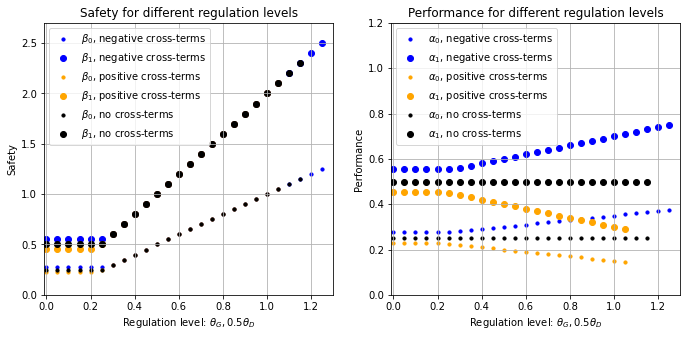

In [1727]:
#epss = list(np.linspace(0,1,11))+list(np.linspace(0.05,0.95,10))+list(np.linspace(1.05,1.5,10))
fix,ax = plt.subplots(1,2,figsize=[11.4,5])

ax[0].scatter(epss,beta_0_negs,label='$\\beta_0$, negative cross-terms',s=10,c='blue')
ax[0].scatter(epss,beta_1_negs,label='$\\beta_1$, negative cross-terms',c='blue')
ax[0].scatter(epss,beta_0_poss,label='$\\beta_0$, positive cross-terms',s=10,c='orange')
ax[0].scatter(epss,beta_1_poss,label='$\\beta_1$, positive cross-terms',c='orange')
#ax[0].scatter(epss,beta_0_superposs,label='$\\beta_0$, super-positive cross-terms',s=10,c='red')
#ax[0].scatter(epss,beta_1_superposs,label='$\\beta_1$, super-positive cross-terms',c='red')
ax[0].scatter(epss,beta_0_canons,label='$\\beta_0$, no cross-terms',s=10,c='black')
ax[0].scatter(epss,beta_1_canons,label='$\\beta_1$, no cross-terms',c='black')
ax[0].set_xlabel("Regulation level: $\\theta_G, 0.5\\theta_D$ ")
ax[0].set_ylabel("Safety")
ax[0].legend(loc = 'upper left')#loc='upper left')
    #bbox_to_anchor=[3,.5])
ax[0].grid()
ax[0].set_ylim([0.,2.7])
ax[0].set_xlim([-0.01,1.3])
ax[0].set_title("Safety for different regulation levels")

plt.scatter(epss,alpha_0_negs,label='$\\alpha_0$, negative cross-terms',s=10,c='blue')
ax[1].scatter(epss,alpha_1_negs,label='$\\alpha_1$, negative cross-terms',c='blue')
plt.scatter(epss,alpha_0_poss,label='$\\alpha_0$, positive cross-terms',s=10,c='orange')
ax[1].scatter(epss,alpha_1_poss,label='$\\alpha_1$, positive cross-terms',c='orange')
#ax[1].scatter(epss,alpha_0_superposs,label='$\\alpha_0$, super-positive cross-terms',s=10,c='red')
#ax[1].scatter(epss,alpha_1_superposs,label='$\\alpha_1$, super-positive cross-terms',c='red')
ax[1].scatter(epss,alpha_0_canons,label='$\\alpha_0$, no cross-terms',s=10,c='black')
ax[1].scatter(epss,alpha_1_canons,label='$\\alpha_1$, no cross-terms',c='black')
ax[1].set_xlabel("Regulation level: $\\theta_G, 0.5\\theta_D$")
ax[1].set_ylabel("Performance")
ax[1].legend(loc = 'upper left')#
    #bbox_to_anchor=[1,1])
ax[1].grid()
ax[1].set_ylim([0,1.2])
ax[1].set_xlim([-0.01,1.3])
ax[1].set_title("Performance for different regulation levels")
#plt.plot(epss,epss*2)

plt.savefig('multivariate_crossterm_regulation_different_regimes_jun3.png',bbox_inches='tight',dpi=200)


In [1702]:
reg_list_theta_G = [0.4,0.4,0,0]
reg_list_theta_D = [.8,0,.8,0]
regregimes = ['both','G only','D only','no regulation']
crossterms = list(np.round(np.linspace(-0.9,0.9,19),4)) + [0.99,1.01] + list(np.round(np.linspace(1.1,2,10),4))
print(crossterms)
delta = 0.5
r = np.array([1,1])

df_crossterm_analysis = pd.DataFrame(columns=['C_0','C_1','r','theta_G','theta_D', 'delta','crossterm','regregime'
                                              ,'alpha_0','beta_0','alpha_1','beta_1','UG','UD','Gstrategy','Dstrategy'
                                             ])
df_crossterm_analysis['regregime']=[-1]*len(reg_list_theta_G)*len(crossterms)

index = 0
for c in crossterms:
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        print("i: ",i)
        C_0 = np.array([[1-0.0000001,c],[c,1]])
        C_1 = np.array([[1-0.0000001,c],[c,1]])
        gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,reg_list_theta_D[i],reg_list_theta_G[i])
        gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'C_0']=str(C_0)
        df_crossterm_analysis.at[index,'C_1']=str(C_1)
        df_crossterm_analysis.at[index,'crossterm']=float(c)
        df_crossterm_analysis.at[index,'r']=str(r)
        df_crossterm_analysis.at[index,'delta']=float(delta)
        df_crossterm_analysis.at[index,'theta_D']=float(reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'theta_G']=float(reg_list_theta_G[i])
        df_crossterm_analysis.at[index,'alpha_0']=float(gamma_0[0])
        df_crossterm_analysis.at[index,'beta_0']=float(gamma_0[1])
        df_crossterm_analysis.at[index,'alpha_1']=float(gamma_1[0])
        df_crossterm_analysis.at[index,'beta_1']=float(gamma_1[1])
        df_crossterm_analysis.at[index,'UG']=float(u_g0)
        df_crossterm_analysis.at[index,'UD']=float(u_d1)
        df_crossterm_analysis.at[index,'Gstrategy']=stratGex
        df_crossterm_analysis.at[index,'Dstrategy']=stratDex
        df_crossterm_analysis.at[index,'regregime']=str(regregimes[i])
        index= index + 1
    

[-0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99, 1.01, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
c:  -0.9
i:  0
i:  1
i:  2
i:  3
c:  -0.8
i:  0


KeyboardInterrupt: 

In [1712]:
c=-0.75
C_0 = np.array([[1,c],[c,1]])
C_1 = np.array([[1,c],[c,1]])
gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,0,0)
gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,0)

print(gamma_0, u_g0, stratGex)
print(gamma_1, u_d1, stratDex)

[0.25 0.  ] 1.0625 $\beta_0=\theta_G$
[1.25 1.  ] 0.625 unconstrained


In [1709]:
np.dot(np.linalg.inv(C_0),r)

array([4., 4.])

In [ ]:
df_crossterm_analysis['Regulatory Regime'] = df_crossterm_analysis['regregime']

In [ ]:

fix,ax = plt.subplots(1,2,figsize=[11.4,5])

#sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='alpha_0',hue='Regulatory Regime',linewidth=0,ax=ax[0],s=10)
#sns.scatterplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='D only'],x='crossterm',y='alpha_0',linewidth=0,ax=ax[0],color='black',s=10,zorder=100)
sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='alpha_1',hue='Regulatory Regime',linewidth=0,ax=ax[0])
ax[0].grid()
ax[0].set_title("Performance impact")

ax[0].set_xlim([-0.875,1.6])
ax[0].set_ylim([-0.1,3])
ax[0].set_ylabel('Performance $\\alpha$')

sns.scatterplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='both'],x='crossterm',y='beta_1',hue='Regulatory Regime',linewidth=0,ax=ax[1],s=60)
#sns.scatterplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='D only'],x='crossterm',y='beta_0',ax=ax[1],linewidth=0,color='black',s=10,zorder=100)
sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='beta_1',hue='Regulatory Regime',ax=ax[1],linewidth=0)
ax[1].grid()
ax[1].set_title("Safety impact")
ax[1].set_xlim([-0.875,1.6])
ax[1].set_ylim([-0.1,3])
ax[1].set_ylabel('Safety $\\beta$')


plt.savefig('multivariate_crossterm_regulation_effects_Jun3.png',bbox_inches='tight',dpi=200)



<AxesSubplot:xlabel='crossterm', ylabel='alpha_1'>

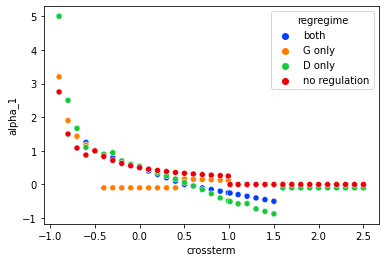

In [1566]:
sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='alpha_1',hue='regregime')

In [1549]:
df_crossterm_analysis

,C_0,C_1,r,theta_G,theta_D,delta,crossterm,alpha_0,beta_0,alpha_1,beta_1,UG,UD,Gstrategy,Dstrategy,C0,C1,U_G,U_D,regregime
49686,NaN,NaN,[1 1],0.0,0.6,0.5,3.0,0.000001,0.506251,0.000001,0.756251,NaN,NaN,"$U_D=0, \alpha_0=0$",unconstrained,[[1. 3.]\n [3. 1.]],[[1. 3.]\n [3. 1.]],0.121833,0.315626,0.6


We want to make the point that divide and conquer happens.

We want to show each player's investment in divide and conquer

For each of the values of the cross-terms, and for each value of regulation


In [1703]:
reg_list_theta_G = [0.4,0.4,0,0]
reg_list_theta_D = [.8,0.4,.8,0]
regregimes = ['Regulating both','Regulating G only','Regulating D only','No regulation']
crossterms = [-0.75,-0.25,0.25,0.75,1.25]
print(crossterms)
delta = 0.5
r = np.array([1,1])

df_crossterm_analysis = pd.DataFrame(columns=['C_0','C_1','r','theta_G','theta_D', 'delta','crossterm','regregime'
                                              ,'alpha_0','beta_0','alpha_1','beta_1','UG','UD','Gstrategy','Dstrategy'
                                             ])
df_crossterm_analysis['regregime']=[-1]*len(reg_list_theta_G)*len(crossterms)

index = 0
for c in crossterms:
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        print("i: ",i)
        C_0 = np.array([[1-0.000001,c],[c,1]])
        C_1 = np.array([[1-0.000001,c],[c,1]])
        gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,reg_list_theta_D[i],reg_list_theta_G[i])
        gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'C_0']=str(C_0)
        df_crossterm_analysis.at[index,'C_1']=str(C_1)
        df_crossterm_analysis.at[index,'crossterm']=float(c)
        df_crossterm_analysis.at[index,'r']=str(r)
        df_crossterm_analysis.at[index,'delta']=float(delta)
        df_crossterm_analysis.at[index,'theta_D']=float(reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'theta_G']=float(reg_list_theta_G[i])
        df_crossterm_analysis.at[index,'alpha_0']=float(gamma_0[0])
        df_crossterm_analysis.at[index,'beta_0']=float(gamma_0[1])
        df_crossterm_analysis.at[index,'alpha_1']=float(gamma_1[0])
        df_crossterm_analysis.at[index,'beta_1']=float(gamma_1[1])
        df_crossterm_analysis.at[index,'UG']=float(u_g0)
        df_crossterm_analysis.at[index,'UD']=float(u_d1)
        df_crossterm_analysis.at[index,'Gstrategy']=stratGex
        df_crossterm_analysis.at[index,'Dstrategy']=stratDex
        df_crossterm_analysis.at[index,'regregime']=str(regregimes[i])
        index= index + 1
    

[-0.75, -0.25, 0.25, 0.75, 1.25]
c:  -0.75
i:  0
i:  1
i:  2
i:  3
c:  -0.25
i:  0


KeyboardInterrupt: 

In [1704]:
df_crossterm_analysis

,C_0,C_1,r,theta_G,theta_D,delta,crossterm,regregime,alpha_0,beta_0,alpha_1,beta_1,UG,UD,Gstrategy,Dstrategy
0,[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[1 1],0.4,0.8,0.5,-0.75,Regulating both,1.000002,1.000002,2.000005,2.000003,1.500003,1.500003,unconstrained,unconstrained
1,[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[1 1],0.4,0.4,0.5,-0.75,Regulating G only,1.000002,1.000002,2.000005,2.000003,1.500003,1.500003,unconstrained,unconstrained
2,[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[1 1],0.0,0.8,0.5,-0.75,Regulating D only,1.000002,1.000002,2.000005,2.000003,1.500003,1.500003,unconstrained,unconstrained
3,[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[[ 0.999999 -0.75 ]\n [-0.75 1. ]],[1 1],0.0,0.0,0.5,-0.75,No regulation,0.25,0.0,1.250003,1.000002,1.062502,0.625001,$\beta_0=\theta_G$,unconstrained
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


c:  0
c:  1
c:  2
c:  3
c:  4


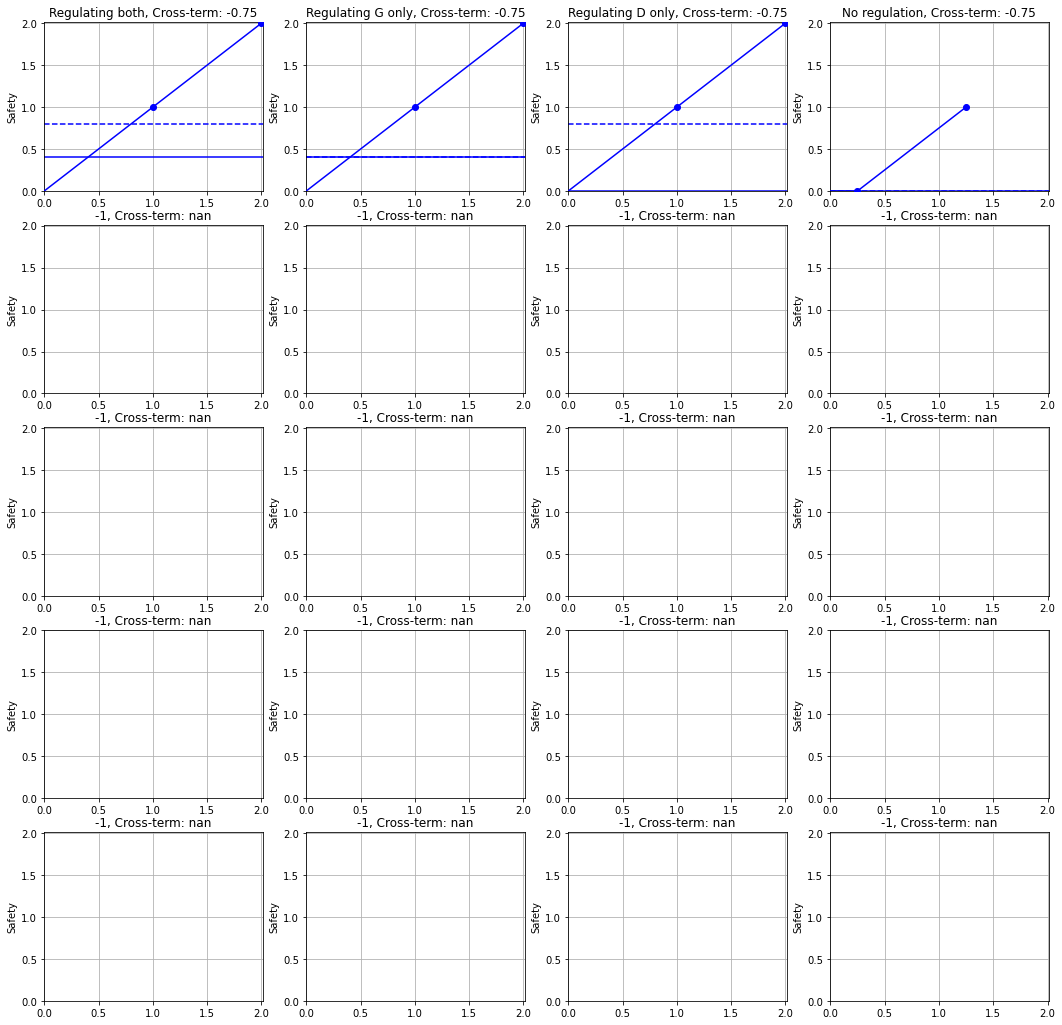

In [1705]:
fig, ax = plt.subplots(5,4,figsize=[18,18])

index = 0
for c in range(len(crossterms)):
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        ax[c,i].set_title("%s, Cross-term: %1.2f" %(df_crossterm_analysis.loc[index,'regregime'],df_crossterm_analysis.loc[index,'crossterm']))
        alpha_0 = df_crossterm_analysis.loc[index,'alpha_0']
        beta_0 = df_crossterm_analysis.loc[index,'beta_0']
        alpha_1 = df_crossterm_analysis.loc[index,'alpha_1']
        beta_1 = df_crossterm_analysis.loc[index,'beta_1']
        ax[c,i].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
        ax[c,i].scatter(alpha_0,beta_0,c='b',zorder=100)
        ax[c,i].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='b',zorder=10)
        ax[c,i].scatter(alpha_1,beta_1,c='b',zorder=100)

        ax[c,i].axhline(df_crossterm_analysis.loc[index,'theta_G'],c='b',ls='-')
        ax[c,i].axhline(df_crossterm_analysis.loc[index,'theta_D'],c='b',ls='--')
        ax[c,i].set_xlim([0,2.01])
        ax[c,i].set_ylim([0,2.01])
        ax[c,i].grid()
        #ax[c,i].set_xticks(np.linspace(0,3,31))
        #ax[c,i].set_yticks(np.linspace(0,3,31))
        ax[c,i].set_ylabel('Safety')
        index = index+1
        

Text(0.5, 1.0, 'Performance for different regulation levels')

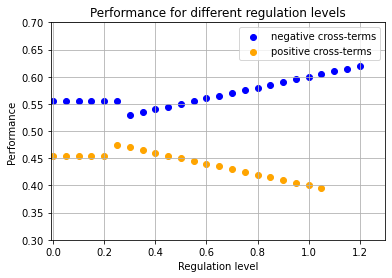

In [1489]:
#plt.scatter(epss,alpha_0_negs,label='positive cross-terms',s=10,c='blue')
plt.scatter(epss,alpha_1_negs,label='negative cross-terms',c='blue')
#plt.scatter(epss,alpha_0_poss,label='positive cross-terms',s=10,c='orange')
plt.scatter(epss,alpha_1_poss,label='positive cross-terms',c='orange')
plt.xlabel("Regulation level")
plt.ylabel("Performance")
plt.legend(bbox_to_anchor=[1,1])
plt.grid()
plt.ylim([0.3,0.7])
plt.xlim([-0.01,1.3])
plt.title("Performance for different regulation levels")

In [1440]:
C_0 = np.array([[1,.1],[.1,1]])
C_1 = np.array([[1,.1],[.1,1]])
delta = 0.5
theta = 0#.01#1.5
thetaG = 0#.4
r = np.array([1,1])

gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,theta,thetaG)
print(gamma_0, u_g0, stratGex )
print()
print(D_strategy(gamma_0,C_1,r,delta,theta))

[0.22727273 0.22727273] 0.34090909090909094 unconstrained

(array([0.45454545, 0.45454545]), 0.34090909090909094, 'unconstrained')


In [1108]:
pd.set_option('display.max_columns', None)
results_utilitarian[(results_utilitarian['U_D']>0.4)&(results_utilitarian['thetaG']==0)]


,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian,U_G_max,U_D_max,utilitarian_max,nash_max,egalitarian_max,U_pareto,U_pareto_dominates_anarchy,U_dominates_anarchy
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.375,0.4,0.0,0.1875,0.5,0.5,0.304688,0.429688,unconstrained,unconstrained,0.1875,0.734375,0.13092,0.304688,0.568974,0.499688,0.734375,0.13092,0.304688,0,0,0


In [1115]:
results_with_bargaining[(results_with_bargaining['theta']==0.5)&(results_with_bargaining['thetaG']==0)
                        #&(results_with_bargaining['delta']==0.375)
                       ]


,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian
195,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.025,0.5,0.0,0.0125,0.5,0.5,0.024844,0.487344,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.512188,0.012107,0.024844
196,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.5,0.0,0.025,0.5,0.5,0.049375,0.474375,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.52375,0.023422,0.049375
197,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.075,0.5,0.0,0.0375,0.5,0.5,0.073594,0.461094,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.534687,0.033934,0.073594
198,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.1,0.5,0.0,0.05,0.5,0.5,0.0975,0.4475,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.545,0.043631,0.0975
199,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.125,0.5,0.0,0.0625,0.5,0.5,0.121094,0.433594,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.554688,0.052505,0.121094
200,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.15,0.5,0.0,0.075,0.5,0.5,0.144375,0.419375,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.56375,0.060547,0.144375
201,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.175,0.5,0.0,0.0875,0.5,0.5,0.167344,0.404844,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.572187,0.067748,0.167344
202,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.2,0.5,0.0,0.1,0.5,0.5,0.19,0.39,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.58,0.0741,0.19
203,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.225,0.5,0.0,0.1125,0.5,0.5,0.212344,0.374844,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.587187,0.079596,0.212344
204,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.25,0.5,0.0,0.125,0.5,0.5,0.234375,0.359375,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.00000,0.59375,0.084229,0.234375


In [1112]:
#results_utilitarian[(results_utilitarian['alpha_1']>0.6)&(results_utilitarian['beta_1']<1.35)]


In [960]:
gamma_0, UG, strategyG = G_strategy(C_0,C_1,r=np.array([1,1]),delta=0.625,theta=1.1,thetaG=0.3)
gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r=np.array([1,1]),delta=0.625,theta=0)
print(gamma_0, UG, strategyG)
print(gamma_1, UD, strategyD)

[0.5129266666666666, 0.30001] 0.772166901188889 $U_D=0, \beta_0=\theta_G$
[0.70042667 0.48751   ] 0.37516375 unconstrained


<AxesSubplot:xlabel='theta', ylabel='thetaG'>

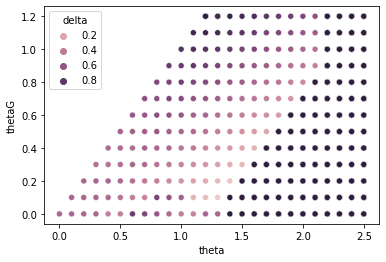

In [961]:
sns.scatterplot(data=results_utilitarian,x='theta',y='thetaG',hue='delta')

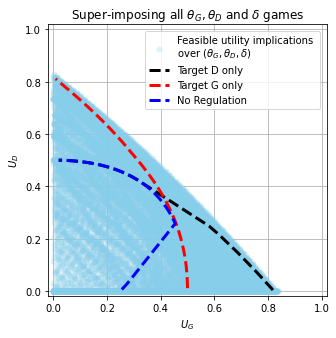

In [1423]:
from scipy.spatial import ConvexHull

fix,ax = plt.subplots(1,1,figsize=[5,5])

plt.grid()

sns.scatterplot(data=results_with_bargaining,x='U_G',y='U_D',alpha=.25,color='skyblue',label='Feasible utility implications \nover $(\\theta_G,\\theta_D,\\delta)$',linewidth=0,zorder=2)
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['thetaG']==0)],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta,\\theta_D$',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['theta']==results_with_bargaining['thetaG'])],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta,\\theta_G$',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0)],x='U_G',y='U_D',alpha=1,label='Feasible utility implications over $\\delta$ in anarchy',linewidth=0)
#sns.scatterplot(data=results_with_bargaining[np.multiply(results_with_bargaining['U_G'],results_with_bargaining['U_D'])==np.max(np.multiply(results_with_bargaining['U_G'],results_with_bargaining['U_D']))],x='U_G',y='U_D',color='red',label="Bargaining Solution")


plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['thetaG']==0)&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(results_with_bargaining.loc[results_with_bargaining['thetaG']==0,['U_G','U_D']])
plt.plot(plot_hull_data.iloc[G_convhull.vertices[3:],0], plot_hull_data.iloc[G_convhull.vertices[3:],1],linestyle='--',color='black',lw=3,label='Target D only',zorder=10)

plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['theta']==results_with_bargaining['thetaG'])&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(plot_hull_data)
plt.plot(plot_hull_data.iloc[G_convhull.vertices[7:-2],0], plot_hull_data.iloc[G_convhull.vertices[7:-2],1],'r--', lw=3,label='Target G only',zorder=10)

plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0)&(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
G_convhull = ConvexHull(results_with_bargaining.loc[(results_with_bargaining['theta']==0)&(results_with_bargaining['thetaG']==0),['U_G','U_D']])
plt.plot(plot_hull_data.iloc[G_convhull.vertices[1:],0], plot_hull_data.iloc[G_convhull.vertices[1:],1],'b--', lw=3,label='No Regulation',zorder=10)

#plot_hull_data = results_with_bargaining.loc[(results_with_bargaining['U_G']>=0),['U_G','U_D']].reset_index(drop=True)
#G_convhull = ConvexHull(results_with_bargaining.loc[results_with_bargaining['U_G']>=0,['U_G','U_D']])
#plt.plot(plot_hull_data.iloc[G_convhull.vertices[9:-1],0], plot_hull_data.iloc[G_convhull.vertices[9:-1],1],'y--', lw=3,label='Target both')

#plt.plot(np.linspace(0,0.83,100),np.linspace(0.83,0,100))
plt.xlim([-0.02,1.02])
plt.ylim([-0.02,1.02])
plt.title("Super-imposing all $\\theta_G, \\theta_D$ and $\\delta$ games")
plt.legend(bbox_to_anchor=[.33,.995])
plt.xlabel("$U_G$")
plt.ylabel("$U_D$")

plt.savefig('multivariate_analysis_pareto_regulation_improves_feb9.png',bbox_inches='tight',dpi=200)


In [846]:
results_with_bargaining[(results_with_bargaining['U_G']<0)&(results_with_bargaining['U_D']>0)]


,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian
627,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.3,0.3,-0.1,0.375,0.375,-0.1,0.26125,abstain,unconstrained,-0.1,0.16125,-0.026125,-0.1
646,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.52,0.3,-0.1,0.375,0.52,-0.1,0.240225,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.140225,-0.024022,-0.1
665,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.74,0.3,-0.1,0.375,0.74,-0.1,0.128025,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.028025,-0.012803,-0.1
836,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.4,0.4,-0.1,0.375,0.4,-0.1,0.260625,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.160625,-0.026063,-0.1
837,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.1,0.4,0.4,-0.1,0.35,0.4,-0.1,0.2225,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.1225,-0.02225,-0.1
855,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.61,0.4,-0.1,0.375,0.61,-0.1,0.206025,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.106025,-0.020603,-0.1
856,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.1,0.61,0.4,-0.1,0.35,0.61,-0.1,0.1574,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.0574,-0.01574,-0.1
874,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.82,0.4,-0.1,0.375,0.82,-0.1,0.063225,abstain,constrained $\alpha_1=\alpha_0$,-0.1,-0.036775,-0.006323,-0.1
875,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.1,0.82,0.4,-0.1,0.35,0.82,-0.1,0.0041,abstain,constrained $\alpha_1=\alpha_0$,-0.1,-0.0959,-0.00041,-0.1
1045,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.05,0.5,0.5,-0.1,0.375,0.5,-0.1,0.245625,abstain,constrained $\alpha_1=\alpha_0$,-0.1,0.145625,-0.024563,-0.1


One comparison with bargaining and everything, establishing the beneficial effects of regulation: $$\theta_G=0.5, \theta = 1$$

In [721]:
C_0 = np.array([[1,0],[0,1]])
C_1 = np.array([[1,0],[0,1]])
delta = 1
theta = .5
thetaG = 0
r = np.array([1,1])

results_onecomparison = pd.DataFrame(columns=['C0','C1','r','delta','theta','thetaG','alpha_0','alpha_1','beta_1','U_G','U_D','Gstrategy','Dstrategy'])
results_onecomparison['C0']=[None]*10000


for threshold_settings in range(2):
    if threshold_settings==1:
        t = 1
        gt = 0.5
    else:
        t = 0
        gt = 0
    for d in np.linspace(0.01,.99,99):
        print(d)
        gamma_0, UG, strategyG = G_strategy(C_0,C_1,r,d,t,gt)
        gamma_1, UD, strategyD = D_strategy(gamma_0,C_1,r,d,t)
        alpha_0 = gamma_0[0]
        beta_0 = gamma_0[1]
        alpha_1 = gamma_1[0]
        beta_1 = gamma_1[1]
        results_onecomparison.at[index,'C0']=str(C_0)
        results_onecomparison.at[index,'C1']=str(C_1)
        results_onecomparison.at[index,'r']=str(r)
        results_onecomparison.at[index,'delta']=d
        results_onecomparison.at[index,'theta']=t
        results_onecomparison.at[index,'thetaG']=gt
        results_onecomparison.at[index,'alpha_0']=float(alpha_0)
        results_onecomparison.at[index,'beta_0']=float(beta_0)
        results_onecomparison.at[index,'alpha_1']=float(alpha_1)
        results_onecomparison.at[index,'beta_1']=float(beta_1)
        results_onecomparison.at[index,'U_G']=float(UG)
        results_onecomparison.at[index,'U_D']=float(UD)
        results_onecomparison.at[index,'Gstrategy']=strategyG
        results_onecomparison.at[index,'Dstrategy']=strategyD
        index = index + 1    
    

0.01
0.02
0.03
0.04
0.05
0.060000000000000005
0.06999999999999999
0.08
0.09
0.09999999999999999
0.11
0.12
0.13
0.14
0.15000000000000002
0.16
0.17
0.18000000000000002
0.19
0.2
0.21000000000000002
0.22
0.23
0.24000000000000002
0.25
0.26
0.27
0.28
0.29000000000000004
0.3
0.31
0.32
0.33
0.34
0.35000000000000003
0.36000000000000004
0.37
0.38
0.39
0.4
0.41000000000000003
0.42000000000000004
0.43
0.44
0.45
0.46
0.47000000000000003
0.48000000000000004
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.5700000000000001
0.5800000000000001
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.6900000000000001
0.7000000000000001
0.7100000000000001
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.8200000000000001
0.8300000000000001
0.8400000000000001
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.9400000000000001
0.9500000000000001
0.9600000000000001
0.97
0.98
0.99
0.01
0.02
0.03
0.04
0.05
0.060000000000000005
0.06999999999999999
0.08
0.09
0.09999999999999999
0.11
0.12
0.13
0.14
0.15000000000000002
0.16
0.17
0

<AxesSubplot:xlabel='U_G', ylabel='U_D'>

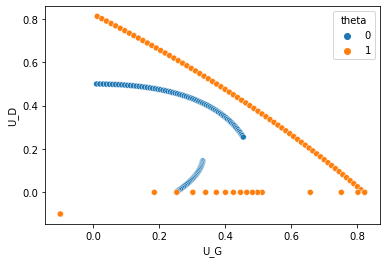

In [751]:
sns.scatterplot(data=results_onecomparison,x='U_G',y='U_D',hue='theta')


In [762]:
#results_onecomparison

In [775]:
results_onecomparison['utilitarian'] = results_onecomparison['U_G'] + results_onecomparison['U_D']
results_onecomparison['nash'] = results_onecomparison['U_G'] * results_onecomparison['U_D']
results_onecomparison['egalitarian'] = np.minimum(results_onecomparison['U_G'], results_onecomparison['U_D'])

joint_utility_maxima = results_onecomparison.groupby(['theta']).max()[['U_G','U_D','utilitarian','nash','egalitarian']]
results_onecomparison_merged = pd.merge(results_onecomparison, joint_utility_maxima, on = ['theta'],suffixes=('','_max'))

results_util = results_onecomparison[results_onecomparison_merged['nash']==results_onecomparison_merged['nash_max']]
results_util = results_util.dropna()
results_util = results_util.reset_index(drop=True)
results_util


,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,beta_0,utilitarian,nash,egalitarian
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,0,0,0.25,0.5,0.5,0.375,0.375,unconstrained,unconstrained,0.25,0.75,0.140625,0.375
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1,0.5,0.25,0.5,1.0,0.4375,0.4375,$\beta_0=\theta_G$,constrained $\alpha_1=\alpha_0$,0.50,0.875,0.191406,0.4375


0    0.5
1    0.5
Name: delta, dtype: object
0     0.375
1    0.4375
Name: U_G, dtype: object


Text(0.5, 1.0, 'Comparing regulation to anarchy with varying $\\delta\\in(0,1)$')

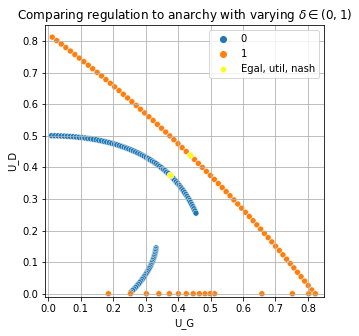

In [853]:
fix,ax = plt.subplots(1,1,figsize=[5,5])

sns.scatterplot(data=results_onecomparison,x='U_G',y='U_D',hue='theta',label='')

results_util = results_onecomparison[results_onecomparison_merged['utilitarian']==results_onecomparison_merged['utilitarian_max']].dropna().reset_index(drop=True)
sns.scatterplot(data=results_util,x='U_G',y='U_D',color='green'#,label='Util'
               )

results_util = results_onecomparison[results_onecomparison_merged['nash']==results_onecomparison_merged['nash_max']].dropna().reset_index(drop=True)
sns.scatterplot(data=results_util,x='U_G',y='U_D',color='red'#,label='Nash'
               )

results_util = results_onecomparison[results_onecomparison_merged['egalitarian']==results_onecomparison_merged['egalitarian_max']].dropna().reset_index(drop=True)
sns.scatterplot(data=results_util,x='U_G',y='U_D',color='yellow',label='Egal, util, nash'
               )
print(results_util['delta'])
print(results_util['U_G'])

#plt.legend(['','Anarchy','Regulation: $\\theta_G=0.5,\\theta_D=1$'])
plt.grid()
plt.xlim([-0.01,.85])
plt.ylim([-0.01,.85])

plt.title("Comparing regulation to anarchy with varying $\\delta\in(0,1)$")


0    0.5
1    0.5
Name: delta, dtype: object


Text(0.5, 1.0, 'Comparing regulation to anarchy with varying $\\delta\\in(0,1)$')

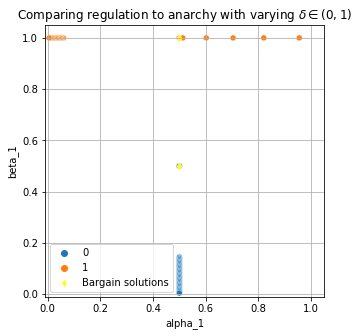

In [831]:
fix,ax = plt.subplots(1,1,figsize=[5,5])

sns.scatterplot(data=results_onecomparison,x='alpha_1',y='beta_1',hue='theta',label='')

results_util = results_onecomparison[results_onecomparison_merged['egalitarian']==results_onecomparison_merged['egalitarian_max']].dropna().reset_index(drop=True)
sns.scatterplot(data=results_util,x='alpha_1',y='beta_1',color='yellow',alpha=1,label='Bargain solutions',marker='d'
               )
print(results_util['delta'])

#plt.legend(['','Anarchy','Regulation: $\\theta_G=0.5,\\theta_D=1$'])
plt.grid()
plt.xlim([-0.01,1.05])
plt.ylim([-0.01,1.05])

plt.title("Comparing regulation to anarchy with varying $\\delta\in(0,1)$")

In [609]:
#results_with_bargaining.to_csv('multi_dimension_with_bargaining_data_NEW.csv')

KeyError: 'U_dominates_anarchy'

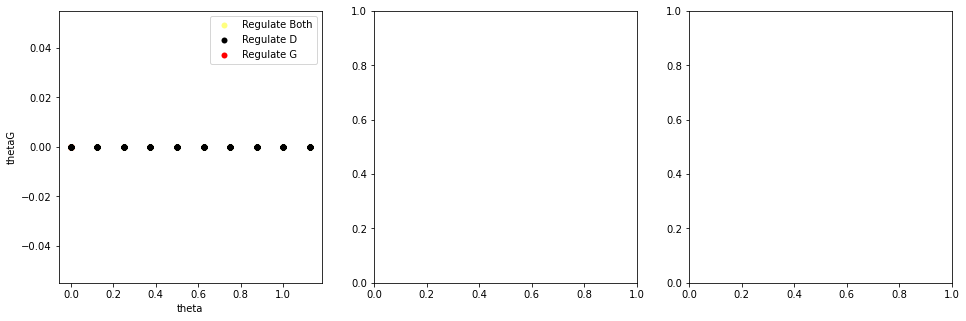

In [610]:
fix,ax = plt.subplots(1,3,figsize=[16,5])

sns.scatterplot(data=G_strategy_results[G_strategy_results['U_D']>=0],x='theta',y='thetaG',alpha=.5,color='yellow',label='Regulate Both',linewidth=0,ax=ax[0],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='theta',y='thetaG',color='black',alpha=1,linewidth=0,label='Regulate D',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='theta',y='thetaG',color='red',linewidth=0,alpha=1,label='Regulate G',ax=ax[0],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_dominates_anarchy']==1)],x='theta',y='thetaG',color='orange',linewidth=0,alpha=1,label='All util-improving regs',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='theta',y='thetaG',color='green',alpha=1,label='Pareto-opt improvement',ax=ax[0],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.01)&(G_strategy_results['thetaG']<0.01)],x='theta',y='thetaG',color='blue',alpha=1,label='Anarchy',ax=ax[0],zorder=6)
ax[0].set_xlabel("Domain-specialist Regulatory Threshold $\\theta_D$")
ax[0].set_ylabel("Generalist Regulatory Threshold $\\theta_G$")
ax[0].grid(zorder=-10)
ax[0].set_title("Feasible Regulation Space")
ax[0].legend()
ax[0].set_ylim([-0.01,1.3])
ax[0].set_xlim([-0.013,2.5])


ax[1].grid(zorder=-10)
sns.scatterplot(data=G_strategy_results,x='U_D',y='U_G',color='yellow',alpha=.5,label='Regulate Both',ax=ax[1])
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='U_D',y='U_G',color='black',linewidth=0,alpha=1,label='Regulate D',ax=ax[1],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='U_D',y='U_G',color='red',linewidth=0,alpha=1,label='Regulate G',ax=ax[1],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_dominates_anarchy']==1)],x='U_D',y='U_G',color='orange',linewidth=0,alpha=1,label='All util-improving regs',ax=ax[1],zorder=5)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='U_D',y='U_G',color='green',alpha=1,label='Pareto-opt improvement',ax=ax[1],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='U_D',y='U_G',color='blue',alpha=1,label='Anarchy',ax=ax[1],zorder=6)
ax[1].set_xlim([-0.005,.8])
ax[1].set_ylim([-0.005,.85])
ax[1].set_title("Attainable Utility Pairs")
ax[1].set_xlabel('$U_D$')
ax[1].set_ylabel('$U_G$')

sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)],x='alpha_1',y='beta_1',color='yellow',alpha=.5,label='Regulate Both',linewidth=0,ax=ax[2],zorder=6)
#sns.scatterplot(data=G_strategy_results[G_strategy_results['U_dominates_anarchy']==1],x='alpha_1',y='beta_1',color='orange',alpha=1,ax=ax[2],linewidth=0,label='Improvement region',zorder=7)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['thetaG']==0)],x='alpha_1',y='beta_1',color='black',alpha=1,label='Regulate D',linewidth=0,ax=ax[2],zorder=6)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<=G_strategy_results['thetaG'])],x='alpha_1',y='beta_1',color='red',alpha=1,label='Regulate G',linewidth=0,ax=ax[2],zorder=8)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['U_pareto_dominates_anarchy']==1)],x='alpha_1',y='beta_1',color='green',alpha=1,label='Pareto-opt \nimprovement',ax=ax[2],zorder=8)
sns.scatterplot(data=G_strategy_results[(G_strategy_results['U_D']>=0)&(G_strategy_results['theta']<0.1)&(G_strategy_results['thetaG']<0.1)],x='alpha_1',y='beta_1',color='blue',alpha=1,label='Anarchy',ax=ax[2],zorder=8)
ax[2].grid()
ax[2].set_xlim([-0.005,.8])
ax[2].set_ylim([-0.015,2.5])
ax[2].set_title("Attainable Performance, Safety Pairs")
ax[2].set_xlabel('$\\alpha_1$')
ax[2].set_ylabel('$\\beta_1$')

plt.savefig('multivariate_analysis_pareto_regulation_withbargaining_jun3.png',bbox_inches='tight',dpi=200)

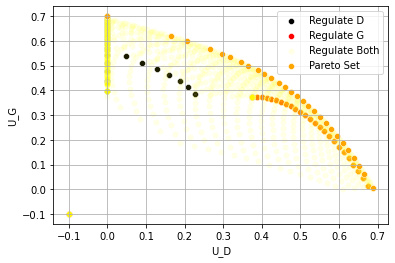

In [204]:
results_manip.groupby('U_G')

In [205]:
results_manip

,C0,C1,r,delta,theta,thetaG,alpha_0,alpha_1,beta_1,U_G,U_D,Gstrategy,Dstrategy,C_0,beta_0
0,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.2775,0.3,0.341977,0.591977,1.2775,0.699746,0.000024,$U_D=0$,constrained $\alpha_1=\alpha_0$,None,0.343576
1,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.278125,0.075,0.342074,0.592074,1.278125,0.699744,0.000024,$U_D=0$,constrained $\alpha_1=\alpha_0$,None,0.344007
2,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.27,0.175,0.340817,0.590817,1.27,0.69974,0.000024,$U_D=0$,constrained $\alpha_1=\alpha_0$,None,0.338397
3,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.28,0.2,0.342363,0.592363,1.28,0.699735,0.000024,$U_D=0$,constrained $\alpha_1=\alpha_0$,None,0.345303
4,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.26875,0.05,0.340623,0.590623,1.26875,0.699733,0.000024,$U_D=0$,constrained $\alpha_1=\alpha_0$,None,0.337534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.5,1.0,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,None,-0.100000
1677,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.525,1.0,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,None,-0.100000
1678,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.55,1.0,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,None,-0.100000
1679,[[1 0]\n [0 1]],[[1 0]\n [0 1]],[1 1],0.5,1.575,1.0,-0.1,-0.1,-0.1,-0.1,-0.1,abstain,abstain,None,-0.100000


In [143]:
D_strategy(np.array([0.4,0.4]),C_1,r,delta,theta)

([-0.1, -0.1], -0.1, 'abstain')

In [ ]:
#sns.scatterplot(data=G_strategy_results,x='alpha_1',y='beta_1',hue='theta')

In [ ]:
D_strategy(np.array([0.25,0.25]),np.array([[1,0],[0,1]]),np.array([1,1]),0.5,1.1)

In [ ]:
#Try using a solver


In [ ]:
def get_candidates(C_0,C_1,delta,r,theta,thetaG):
    C_0_rat = np.array([[Rational(C_0[0,0]),Rational(C_0[0,1])],[Rational(C_0[1,0]),Rational(C_0[1,1])]])
    C_1_rat = np.array([[Rational(C_1[0,0]),Rational(C_1[0,1])],[Rational(C_1[1,0]),Rational(C_1[1,1])]])
    delta_rat = Rational(delta)#0.5
    theta_rat = Rational(theta)
    thetaG_rat = Rational(thetaG)
    r_rat = np.array([Rational(r[0]),Rational(r[1])])
    equation_1 = delta_rat*r_rat[0]-2*C_0_rat[0,0]*a - 2*C_0_rat[0,1]*b-l*(1-delta_rat)*r_rat[0]
    equation_2 = (delta_rat*C_1_rat[0,1]*r_rat[0]/C_1_rat[0,0]) - 2*C_0_rat[1,1]*b - 2*C_0_rat[0,1]*a - l*(C_1_rat[0,1]*(1-delta_rat)*r_rat[0]/C_1_rat[0,0] - 2*C_1_rat[0,1]**2 * theta_rat/C_1_rat[0,0] + 2*C_1_rat[1,1]*theta_rat + 2*(C_1_rat[0,1]/C_1_rat[0,0]-C_1_rat[1,1])*b)
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1_rat,r_rat,delta_rat,theta_rat)
    equation_3 = term0*a + termA*b**2 + termB*b + termC
    raw_results = nonlinsolve([equation_1,equation_2,equation_3],a,b,l)
    raw_results = list(raw_results)
    results = [[float(j) for j in raw_results[i][:2]] for i in range(len(raw_results))]
    return results

In [ ]:
C_0 = np.array([[1,0],[0,1]])
C_1 = np.array([[1,0],[0,1]])
delta = 0.5
theta = 1.5
thetaG = 0
r = np.array([1,1])

print(get_candidates(C_0,C_1,delta,r,theta,thetaG))

In [ ]:
list(x)[0]

In [ ]:
[Eq(b,0), Eq((b+1)*a**2-5,0)]